# Minibatch Training: From Basic Loops to PyTorch DataLoaders

## What is this notebook about?

This notebook teaches you how to **train a neural network properly**. While previous notebooks covered forward passes and backpropagation, this notebook covers everything else needed for real training:

1. **Cross-Entropy Loss**: The correct loss function for classification problems
2. **Training Loops**: How to iterate through data and update weights
3. **Optimizers**: Using PyTorch's built-in optimization algorithms
4. **Datasets & DataLoaders**: Efficiently loading and batching data
5. **Validation**: Measuring how well your model generalizes to new data

---

## Key Concepts (Glossary)

Before we dive in, let's define some important terms you'll encounter throughout this notebook:

| Term | Definition |
|------|------------|
| **Minibatch** | A small subset of training data processed together (e.g., 50 images at a time) |
| **Epoch** | One complete pass through all training data |
| **Cross-Entropy** | Loss function specifically designed for classification problems |
| **Softmax** | Function that converts raw scores to probabilities that sum to 1 |
| **Logits** | Raw output scores from the model before converting to probabilities |
| **Learning Rate** | How big a step we take when updating weights (a hyperparameter) |
| **Optimizer** | Algorithm that updates weights (SGD, Adam, etc.) |
| **Dataset** | Abstraction for accessing data samples |
| **DataLoader** | Batches and shuffles data for training |
| **Gradient** | The direction and magnitude of change needed for each weight |

---

## The Training Loop Overview

Here's the big picture of what happens during training:

```
+-----------------------------------------------------------------------------+
|                         THE TRAINING LOOP                                   |
+-----------------------------------------------------------------------------+
|                                                                             |
|   FOR each epoch (complete pass through data):                              |
|   |                                                                         |
|   +-- FOR each minibatch (small chunk of data):                             |
|   |   |                                                                     |
|   |   +-- 1. FORWARD PASS:   predictions = model(inputs)                   |
|   |   |                      Run data through the network                   |
|   |   |                                                                     |
|   |   +-- 2. COMPUTE LOSS:   loss = loss_func(predictions, targets)        |
|   |   |                      Measure how wrong we are                       |
|   |   |                                                                     |
|   |   +-- 3. BACKWARD PASS:  loss.backward()                               |
|   |   |                      Compute gradients for all parameters          |
|   |   |                                                                     |
|   |   +-- 4. UPDATE WEIGHTS: optimizer.step()                              |
|   |   |                      Adjust weights to reduce loss                  |
|   |   |                                                                     |
|   |   +-- 5. ZERO GRADIENTS: optimizer.zero_grad()                         |
|   |                          Clear gradients for next iteration             |
|   |                                                                         |
|   +-- VALIDATE: Check performance on held-out data                          |
|                                                                             |
+-----------------------------------------------------------------------------+
```

---

## Why Use Minibatches?

You might wonder: why not just train on all data at once? Here's why minibatches are essential:

- **Memory Constraints**: Modern datasets are huge! You can't fit 50,000 images in GPU memory at once
- **Faster Updates**: With minibatches, we update weights more frequently (1000 updates vs 1 per epoch)
- **Better Generalization**: The "noise" from minibatch gradients helps escape poor local minima
- **Parallelization**: GPUs are optimized for parallel computation on batches of data

Typical batch sizes range from 16 to 256 depending on your GPU memory and task.

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install the standard packages, and clone the `miniai` library from the fast.ai Part 2 course repo so the `from miniai.X import *` lines work.

**GPU note:** All examples run fine on CPU; no GPU needed.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [3]:
# Install required packages
!pip install -q fastcore fastai diffusers datasets torcheval accelerate

# Clone the fast.ai Part 2 course repo to get the miniai library
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git

# Add miniai to the Python path
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))

# Verify miniai is accessible
try:
    import miniai
    print(f'miniai loaded successfully from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found. Check that course22p2 was cloned correctly.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 5.6 MB/s eta 0:00:00
miniai loaded successfully from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


In [4]:
!pip install nbdev

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.6 MB/s eta 0:00:00


### 🎮 About the interactive cells in this notebook

Sprinkled through this notebook you'll find cells marked **🎮 Interactive**. Each one loads a small, self-contained visualization (an HTML + JavaScript file from the `interactive_viz/` folder that sits next to this notebook) inside an isolated iframe — just **run the cell** and play with the sliders and buttons. They work in Jupyter, JupyterLab, and VS Code; re-run a cell to reset its visualization. The 3D one (SGD on a loss surface) additionally loads three.js from a CDN, so it needs an internet connection. If you move or share this notebook, keep the `interactive_viz/` folder with it (or point the `IFrame(...)` calls at your published GitHub Pages copies, as shown in the comments).

Reading code builds knowledge, but *moving a slider and watching the math respond* builds intuition — use both.

In [5]:
# ============================================================================
# NBDEV EXPORT DIRECTIVE
# ============================================================================
# This special comment tells nbdev to export code from this notebook
# to a Python module. This is how the fast.ai library is built!
#
# What is nbdev?
# - nbdev is a tool that lets you write Python libraries in Jupyter notebooks
# - Code cells marked with #|export get extracted to .py files
# - This notebook exports to a file called "training.py"
#
# You don't need to worry about this for learning - it's just for library development.

#| default_exp training

In [6]:
# ============================================================================
# IMPORTING REQUIRED LIBRARIES
# ============================================================================
# The #|export comment marks this code for export to the training module

#|export
import pickle      # For loading serialized Python objects (our dataset is saved as a pickle file)
import gzip        # For reading compressed .gz files (our dataset is gzip compressed)
import math        # Mathematical functions (we'll use this for some calculations)
import os          # Operating system functions (file paths, etc.)
import time        # For timing code execution
import shutil      # File operations (copy, move, delete)

import torch                    # PyTorch - our deep learning framework
import matplotlib as mpl        # Plotting configuration
import numpy as np              # Numerical operations (we'll use PyTorch mostly)
import matplotlib.pyplot as plt # Plotting functions for visualizations

from pathlib import Path        # Modern file path handling (cleaner than os.path)
from torch import tensor, nn   # tensor: creates tensors, nn: neural network module
import torch.nn.functional as F # Functional operations (loss functions, activations)

# ============================================================================
# UNDERSTANDING THE IMPORTS
# ============================================================================
#
# torch.nn (imported as nn):
#   - Contains neural network building blocks (Linear, Conv2d, ReLU, etc.)
#   - Base classes for creating custom layers (nn.Module)
#   - Built-in loss functions and optimizers
#   - Example: nn.Linear(10, 5) creates a layer that transforms 10 inputs to 5 outputs
#
# torch.nn.functional (imported as F):
#   - Contains the SAME operations as nn, but in "functional" form
#   - F.relu(x) vs nn.ReLU()(x) - same result, different style
#   - F.cross_entropy(), F.softmax(), F.log_softmax(), etc.
#   - Use functional when you don't need to store state (no learnable parameters)
#
# When to use nn vs F:
#   - Use nn.Module when the layer has learnable parameters (weights, biases)
#   - Use F when you just need a stateless transformation
#   - Example: nn.Linear for weights, F.relu for activation

In [7]:
# ============================================================================
# SETUP AND LOAD DATA
# ============================================================================

from fastcore.test import test_close  # Utility to test if two values are close enough

# ============================================================================
# DISPLAY SETTINGS
# ============================================================================
# These settings make tensor output easier to read in the notebook

# precision=2: Show only 2 decimal places (instead of many)
# Example: 0.123456789 becomes 0.12
torch.set_printoptions(precision=2, linewidth=140, sci_mode=False)
#   linewidth=140: Allow 140 characters per line when printing tensors
#   sci_mode=False: Don't use scientific notation (show 0.0001 instead of 1e-4)

# Set random seed for reproducibility
# When you set a seed, "random" numbers become predictable
# Same seed = same "random" sequence = reproducible results
# This is crucial for debugging and comparing experiments!
torch.manual_seed(1)

# Display images in grayscale (MNIST digits are black and white)
mpl.rcParams['image.cmap'] = 'gray'

# ============================================================================
# LOAD MNIST DATASET
# ============================================================================
# MNIST is a famous dataset of handwritten digits (0-9)
# It contains:
#   - 60,000 training images (we'll use 50,000 for training, 10,000 for validation)
#   - 10,000 test images
#   - Each image is 28x28 pixels = 784 values
#   - Each pixel is a grayscale value from 0 (black) to 1 (white)
#   - Labels are integers 0-9 representing the digit

path_data = Path('data')          # Directory where data is stored
path_gz = path_data/'mnist.pkl.gz' # Path to the compressed pickle file

# Load the pickled data from compressed file
# pickle.load() deserializes (unpacks) the Python objects saved in the file
# The file was created by someone who saved: ((train_x, train_y), (valid_x, valid_y), _)
with gzip.open(path_gz, 'rb') as f:  # 'rb' = read binary mode
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1')

# Convert NumPy arrays to PyTorch tensors
# PyTorch requires tensors for all operations
# map() applies the tensor() function to each array in the list
x_train, y_train, x_valid, y_valid = map(tensor, [x_train, y_train, x_valid, y_valid])

print("Data loaded successfully!")
print(f"Training set:   {x_train.shape[0]:,} images, each with {x_train.shape[1]} pixels")
print(f"Validation set: {x_valid.shape[0]:,} images")
print(f"\nFirst training image shape: {x_train[0].shape}")
print(f"First training label: {y_train[0]} (this image shows the digit '{y_train[0].item()}')")

Data loaded successfully!
Training set:   50,000 images, each with 784 pixels
Validation set: 10,000 images

First training image shape: torch.Size([784])
First training label: 5 (this image shows the digit '5')


---

## Part 1: Understanding Our Data and Building a Simple Model

Before we can train a neural network, we need to:
1. Understand the dimensions of our data
2. Build a simple model architecture
3. Define a proper loss function for classification

Let's start by exploring our data dimensions.

In [8]:
# ============================================================================
# UNDERSTANDING DATA DIMENSIONS
# ============================================================================
# These are the key dimensions we need to know for building our model

n, m = x_train.shape  # Unpack the 2D shape into two variables
# n = number of training samples (how many images we have)
# m = number of features per sample (how many pixels per image)

print(f"x_train.shape = {x_train.shape}")
print(f"  n = {n:,} (number of training images)")
print(f"  m = {m} (pixels per image = 28 x 28)")

# Number of output classes
# Our labels are 0, 1, 2, ..., 9 (ten different digits)
# The maximum label is 9, so we have 9 + 1 = 10 classes
c = y_train.max() + 1
print(f"\nc = {c} (number of classes: digits 0-9)")

# Number of hidden neurons (this is a HYPERPARAMETER)
# A hyperparameter is a value WE choose, not something the model learns
# More neurons = more capacity to learn complex patterns
# Fewer neurons = faster training, less risk of overfitting
# 50 is a reasonable starting point for this simple problem
nh = 50
print(f"nh = {nh} (hidden neurons - we chose this)")

print("\n" + "="*60)
print("SUMMARY: Our model will be:")
print(f"  Input:  {m} neurons (one per pixel)")
print(f"  Hidden: {nh} neurons (we chose this)")
print(f"  Output: {c} neurons (one per digit class)")
print("="*60)

x_train.shape = torch.Size([50000, 784])
  n = 50,000 (number of training images)
  m = 784 (pixels per image = 28 x 28)

c = 10 (number of classes: digits 0-9)
nh = 50 (hidden neurons - we chose this)

SUMMARY: Our model will be:
  Input:  784 neurons (one per pixel)
  Hidden: 50 neurons (we chose this)
  Output: 10 neurons (one per digit class)


### Let's Visualize Some Training Data

Before building our model, let's look at what our data actually looks like. Remember, each image is stored as a flat vector of 784 numbers, but originally it's a 28x28 pixel image.

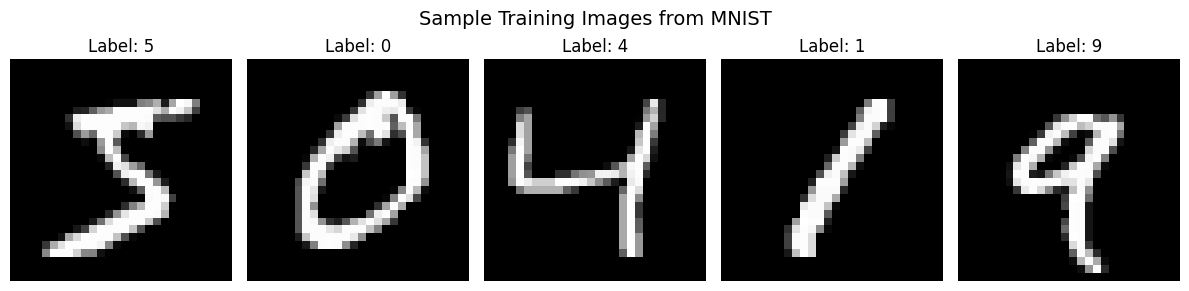

Each image is 28x28 = 784 pixels
Pixel values range from 0 (black) to ~1 (white)
Our model sees these as flat vectors of 784 numbers


In [9]:
# ============================================================================
# VISUALIZING SAMPLE IMAGES
# ============================================================================

# Create a figure with 5 sample images side by side
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, ax in enumerate(axes):
    # Get one image and reshape from flat (784,) to 2D (28, 28)
    # view() reshapes the tensor - same data, different shape
    img = x_train[i].view(28, 28)

    # Display the image
    ax.imshow(img)
    ax.set_title(f"Label: {y_train[i].item()}")
    ax.axis('off')  # Hide axis ticks and numbers

plt.suptitle("Sample Training Images from MNIST", fontsize=14)
plt.tight_layout()
plt.show()

print("Each image is 28x28 = 784 pixels")
print("Pixel values range from 0 (black) to ~1 (white)")
print("Our model sees these as flat vectors of 784 numbers")

### Building Our Neural Network Model

Now let's build a simple 2-layer neural network. This is similar to what we built in previous notebooks, but now the output layer has 10 neurons (one for each digit class) instead of 1.

**Architecture:**
```
Input (784 pixels) --> Linear --> ReLU --> Linear --> Output (10 classes)
```

**Key Concept - Logits:**
The output of our model is called "logits" - these are raw scores, NOT probabilities. A larger logit means the model is more confident about that class. We'll convert these to probabilities later using the softmax function.

In [10]:
# ============================================================================
# SIMPLE NEURAL NETWORK MODEL
# ============================================================================

class Model(nn.Module):
    """
    A simple 2-layer neural network for digit classification.

    Architecture:
        Input (784) --> Linear --> ReLU --> Linear --> Output (10)

    The output layer has 10 neurons - one for each digit (0-9).
    These outputs are called "logits" - raw scores before softmax.
    """

    def __init__(self, n_in, nh, n_out):
        """
        Initialize the model layers.

        Parameters:
        -----------
        n_in : int
            Number of input features (784 for MNIST - one per pixel)
        nh : int
            Number of hidden neurons (50 in our case)
        n_out : int
            Number of output classes (10 for digits 0-9)
        """
        # Call the parent class (nn.Module) constructor
        # This is REQUIRED for PyTorch to track parameters properly
        super().__init__()

        # Create the layers as a list
        # We'll pass data through each layer in sequence
        self.layers = [
            nn.Linear(n_in, nh),  # First layer: 784 inputs --> 50 hidden neurons
            nn.ReLU(),            # Activation function (introduces non-linearity)
            nn.Linear(nh, n_out)  # Second layer: 50 hidden --> 10 output classes
        ]

        # ================================================================
        # What each layer does:
        # ================================================================
        # nn.Linear(784, 50):
        #   - Has 784 * 50 = 39,200 weights + 50 biases = 39,250 parameters
        #   - Computes: output = input @ weights.T + bias
        #   - Transforms 784-dimensional input to 50-dimensional output
        #
        # nn.ReLU():
        #   - ReLU(x) = max(0, x)
        #   - Keeps positive values, sets negative values to 0
        #   - This non-linearity is what makes neural networks powerful!
        #   - Without it, stacking linear layers would collapse to one linear layer
        #
        # nn.Linear(50, 10):
        #   - Has 50 * 10 = 500 weights + 10 biases = 510 parameters
        #   - Outputs 10 values (logits), one per digit class

    def __call__(self, x):
        """
        Forward pass: compute predictions for input x.

        Parameters:
        -----------
        x : tensor
            Input batch of images, shape (batch_size, 784)

        Returns:
        --------
        tensor
            Logits (raw scores), shape (batch_size, 10)
            Each row has 10 values - one score per digit class
        """
        # Pass through each layer in sequence
        for layer in self.layers:
            x = layer(x)  # Output of one layer becomes input to the next
        return x  # Return logits (NOT probabilities yet!)

# Create model instance
model = Model(m, nh, 10)

print("Model created!")
print(f"Architecture: {m} --> {nh} --> 10")
print(f"\nLayers:")
for i, layer in enumerate(model.layers):
    print(f"  {i}: {layer}")

# Count parameters
total_params = sum(p.numel() for layer in model.layers if hasattr(layer, 'weight')
                   for p in [layer.weight, layer.bias])
print(f"\nTotal trainable parameters: {total_params:,}")

Model created!
Architecture: 784 --> 50 --> 10

Layers:
  0: Linear(in_features=784, out_features=50, bias=True)
  1: ReLU()
  2: Linear(in_features=50, out_features=10, bias=True)

Total trainable parameters: 39,760


In [12]:
# Without list comprehension
# Count parameters
total_params = 0
for layer in model.layers:
    if hasattr(layer, 'weight'):
        total_params += layer.weight.numel()
        total_params += layer.bias.numel()
print(f"\nTotal trainable parameters: {total_params:,}")


Total trainable parameters: 39,760


In [13]:
# ============================================================================
# TEST THE MODEL: FORWARD PASS
# ============================================================================
# Let's run all training data through the model to see what it outputs.
# This is called a "forward pass" - data flows forward through the network.

# Run ALL 50,000 training images through the model
# Note: In practice, we'd use minibatches, but this is just a test
pred = model(x_train)

print("Forward pass complete!")
print(f"Input shape:  {x_train.shape}  (50000 images, 784 pixels each)")
print(f"Output shape: {pred.shape}     (50000 images, 10 logits each)")

print("\n" + "="*60)
print("UNDERSTANDING THE OUTPUT:")
print("="*60)
print("Each image now has 10 output values (one per digit class 0-9)")
print("These are called LOGITS - raw scores, NOT probabilities!")
print("\nExample - First image's logits:")
print(pred[0])
print(f"\nTrue label for first image: {y_train[0].item()}")
print("\nThe model hasn't been trained yet, so these are essentially random.")
print("After training, the logit for the correct class should be highest.")

Forward pass complete!
Input shape:  torch.Size([50000, 784])  (50000 images, 784 pixels each)
Output shape: torch.Size([50000, 10])     (50000 images, 10 logits each)

UNDERSTANDING THE OUTPUT:
Each image now has 10 output values (one per digit class 0-9)
These are called LOGITS - raw scores, NOT probabilities!

Example - First image's logits:
tensor([-0.09, -0.21, -0.08,  0.10, -0.04,  0.08, -0.04, -0.03,  0.01,  0.06], grad_fn=<SelectBackward0>)

True label for first image: 5

The model hasn't been trained yet, so these are essentially random.
After training, the logit for the correct class should be highest.


---

## Part 2: Cross-Entropy Loss for Classification

For classification problems, we use **cross-entropy loss** instead of MSE (Mean Squared Error). Cross-entropy is specifically designed for picking one class out of many!

### Step 1: Softmax - Converting Logits to Probabilities

The **softmax** function converts raw scores (logits) into probabilities that:
1. Are all positive (between 0 and 1)
2. Sum to 1.0 (like proper probabilities should)
3. Preserve the ordering (larger logits become larger probabilities)

**The Softmax Formula:**

$$\text{softmax}(x)_i = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**Step-by-step Example:**

If logits are `[2.0, 1.0, 0.1]` (for a 3-class problem):

1. **Compute exponentials:** `exp([2.0, 1.0, 0.1]) = [7.39, 2.72, 1.10]`
2. **Sum them:** `7.39 + 2.72 + 1.10 = 11.21`
3. **Divide each by sum:** `[7.39/11.21, 2.72/11.21, 1.10/11.21] = [0.66, 0.24, 0.10]`

Result: **66% confident it's class 0, 24% class 1, 10% class 2** (sums to 100%)

```
+-----------------------------------------------------------------------------+
|                    FROM LOGITS TO PROBABILITIES                              |
+-----------------------------------------------------------------------------+
|                                                                             |
|   Logits (raw scores):    [2.0,  1.0,  0.1]   <-- Can be any real numbers  |
|                              |                                              |
|                              v                                              |
|   Exponentials:           [7.39, 2.72, 1.10]  <-- All positive now         |
|                              |                                              |
|                              v                                              |
|   Divide by sum (11.21):  [0.66, 0.24, 0.10]  <-- Sum to 1.0!             |
|                                                                             |
|   Interpretation: 66% class 0, 24% class 1, 10% class 2                    |
|                                                                             |
+-----------------------------------------------------------------------------+
```

In [14]:
# ============================================================================
# UNDERSTANDING SOFTMAX WITH A SIMPLE EXAMPLE
# ============================================================================

# Let's work through a simple example step by step
example_logits = torch.tensor([2.0, 1.0, 0.1])

print("="*60)
print("SOFTMAX STEP-BY-STEP EXAMPLE")
print("="*60)
print(f"Starting with logits: {example_logits.tolist()}")

# Step 1: Compute exponentials
# exp() is the exponential function: e^x where e ≈ 2.718
# This makes all values positive and emphasizes differences
exponentials = example_logits.exp()
print(f"\nStep 1 - Compute exp() of each value:")
print(f"  exp(2.0) = e^2.0 = {torch.exp(torch.tensor(2.0)):.2f}")
print(f"  exp(1.0) = e^1.0 = {torch.exp(torch.tensor(1.0)):.2f}")
print(f"  exp(0.1) = e^0.1 = {torch.exp(torch.tensor(0.1)):.2f}")
print(f"  Result: {exponentials.tolist()}")

# Step 2: Sum them up
exp_sum = exponentials.sum()
print(f"\nStep 2 - Sum all exponentials:")
print(f"  7.39 + 2.72 + 1.11 = {exp_sum:.2f}")

# Step 3: Divide each by the sum
probabilities = exponentials / exp_sum
print(f"\nStep 3 - Divide each by the sum to get probabilities:")
print(f"  7.39 / 11.21 = {probabilities[0]:.2f}")
print(f"  2.72 / 11.21 = {probabilities[1]:.2f}")
print(f"  1.11 / 11.21 = {probabilities[2]:.2f}")
print(f"  Result: {[round(p.item(), 2) for p in probabilities]}")

# Verify they sum to 1
print(f"\nVerification: Sum of probabilities = {probabilities.sum():.4f}")

print("\n" + "="*60)
print("KEY INSIGHTS ABOUT SOFTMAX:")
print("="*60)
print("1. Transforms ANY values into valid probabilities")
print("2. Larger logits -> Larger probabilities")
print("3. Output always sums to 1.0")
print("4. Uses exp() to make all values positive first")

SOFTMAX STEP-BY-STEP EXAMPLE
Starting with logits: [2.0, 1.0, 0.10000000149011612]

Step 1 - Compute exp() of each value:
  exp(2.0) = e^2.0 = 7.39
  exp(1.0) = e^1.0 = 2.72
  exp(0.1) = e^0.1 = 1.11
  Result: [7.389056205749512, 2.7182817459106445, 1.1051709651947021]

Step 2 - Sum all exponentials:
  7.39 + 2.72 + 1.11 = 11.21

Step 3 - Divide each by the sum to get probabilities:
  7.39 / 11.21 = 0.66
  2.72 / 11.21 = 0.24
  1.11 / 11.21 = 0.10
  Result: [0.66, 0.24, 0.1]

Verification: Sum of probabilities = 1.0000

KEY INSIGHTS ABOUT SOFTMAX:
1. Transforms ANY values into valid probabilities
2. Larger logits -> Larger probabilities
3. Output always sums to 1.0
4. Uses exp() to make all values positive first


### 🎮 Interactive: the softmax machine

Drag the three logit sliders and watch the full pipeline: **logits → exp() → divide by sum → probabilities**. Two things to internalize: (1) no matter what numbers you feed in, the output bars are always positive and always total exactly 1.0; (2) press **“+2 to ALL logits”** — the probabilities don't move at all. Softmax only sees the *differences* between logits, a fact the LogSumExp trick will exploit in a few cells.

In [15]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/softmax_playground.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/softmax_playground.html",
#          width="100%", height=760)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/softmax_playground.html", width="100%", height=660)


### Why Use Log-Softmax Instead of Softmax?

In practice, we almost always compute **log(softmax)** instead of just softmax. Here's why:

**1. Numerical Stability:**
- Softmax can produce very small numbers (close to 0)
- When we take log later for the loss, log(tiny number) = very negative number
- This can cause numerical underflow (numbers too small to represent)

**2. Computational Efficiency:**
- The loss function needs log(probabilities)
- By computing log(softmax) directly, we combine two operations into one
- This is faster and more accurate

**3. Mathematical Simplification:**
- log(softmax) has a simpler formula than computing softmax then taking log

In [16]:
# ============================================================================
# LOG-SOFTMAX: NAIVE IMPLEMENTATION
# ============================================================================
# This is the direct formula: log(softmax(x)) = log(exp(x) / sum(exp(x)))

def log_softmax_naive(x):
    """
    Compute log-softmax (naive version).

    Parameters:
    -----------
    x : tensor
        Input tensor of logits, shape (batch_size, num_classes)

    Returns:
    --------
    tensor
        Log-probabilities, shape (batch_size, num_classes)
        All values will be negative or zero (since log(p) <= 0 when p <= 1)

    Step by step:
        1. x.exp()                           -> Compute exp(x) for each element
        2. x.exp().sum(-1, keepdim=True)     -> Sum along last dimension (classes)
                                                keepdim=True keeps shape for broadcasting
        3. exp(x) / sum(exp(x))              -> Softmax probabilities
        4. .log()                            -> Take log of probabilities
    """
    # Compute softmax first
    softmax_probs = x.exp() / x.exp().sum(-1, keepdim=True)
    # Then take log
    return softmax_probs.log()

# Test on a small example
# 2 samples, 3 classes each
example = torch.tensor([[2.0, 1.0, 0.1],
                        [1.0, 2.0, 3.0]])

result = log_softmax_naive(example)

print("Input logits (2 samples, 3 classes):")
print(example)
print("\nLog-softmax output:")
print(result)
print("\nNotice: All values are NEGATIVE")
print("This is because log(probability) is always <= 0 since probability <= 1")
print("  - log(1.0) = 0 (max possible)")
print("  - log(0.5) = -0.69")
print("  - log(0.1) = -2.30")
print("\nConverting back to probabilities (exp of log-softmax):")
print(result.exp())
print(f"Sum of each row (should be 1.0): {result.exp().sum(dim=1)}")

Input logits (2 samples, 3 classes):
tensor([[2.00, 1.00, 0.10],
        [1.00, 2.00, 3.00]])

Log-softmax output:
tensor([[-0.42, -1.42, -2.32],
        [-2.41, -1.41, -0.41]])

Notice: All values are NEGATIVE
This is because log(probability) is always <= 0 since probability <= 1
  - log(1.0) = 0 (max possible)
  - log(0.5) = -0.69
  - log(0.1) = -2.30

Converting back to probabilities (exp of log-softmax):
tensor([[0.66, 0.24, 0.10],
        [0.09, 0.24, 0.67]])
Sum of each row (should be 1.0): tensor([1.00, 1.00])


### Simplifying Log-Softmax Using Log Properties

We can simplify the log-softmax formula using the property:

$$\log(a/b) = \log(a) - \log(b)$$

Starting from:
$$\log\left(\frac{e^{x_i}}{\sum_j e^{x_j}}\right)$$

We get:
$$= \log(e^{x_i}) - \log\left(\sum_j e^{x_j}\right)$$
$$= x_i - \log\left(\sum_j e^{x_j}\right)$$

This is more efficient because:
- We only compute `exp()` once (not twice like the naive version)
- We use subtraction instead of division (faster on computers)

In [17]:
# ============================================================================
# LOG-SOFTMAX: SIMPLIFIED VERSION
# ============================================================================
# Using log(a/b) = log(a) - log(b), we get a simpler, more efficient formula
# log(exp(x) / sum(exp(x))) = log(exp(x)) - log(sum(exp(x)))
#                           = x - log(sum(exp(x)))

def log_softmax_v2(x):
    """
    Compute log-softmax (simplified version).

    Formula: log_softmax(x)_i = x_i - log(sum(exp(x)))

    This is more efficient because:
    1. We only compute exp() once (not twice like the naive version)
    2. Subtraction is computationally cheaper than division
    """
    # x.exp() - compute exp for each element
    # .sum(-1, keepdim=True) - sum along last dimension, keep shape for broadcasting
    # .log() - take log of the sum
    # x - ... - subtract from original logits
    return x - x.exp().sum(-1, keepdim=True).log()

# Verify it gives the same result as the naive version
example = torch.tensor([[2.0, 1.0, 0.1],
                        [1.0, 2.0, 3.0]])

naive_result = log_softmax_naive(example)
simplified_result = log_softmax_v2(example)

print("Comparing naive vs simplified log_softmax:")
print("\nNaive version:")
print(naive_result)
print("\nSimplified version:")
print(simplified_result)
print(f"\nAre they equal? {torch.allclose(naive_result, simplified_result)}")
print("\nThe simplified version is more efficient - same result, fewer operations!")

Comparing naive vs simplified log_softmax:

Naive version:
tensor([[-0.42, -1.42, -2.32],
        [-2.41, -1.41, -0.41]])

Simplified version:
tensor([[-0.42, -1.42, -2.32],
        [-2.41, -1.41, -0.41]])

Are they equal? True

The simplified version is more efficient - same result, fewer operations!


### The Problem with Large Logits: Numerical Overflow

There's still a problem with our log-softmax: if logits are very large (e.g., 1000), then `exp(1000)` overflows to infinity!

Let's see this problem in action:

In [18]:
# ============================================================================
# DEMONSTRATING THE OVERFLOW PROBLEM
# ============================================================================

# What happens with large logits?
large_logits = torch.tensor([1000.0, 1001.0, 1002.0])

print("Large logits:", large_logits.tolist())
print("\nTrying to compute exp():")
print(f"  exp(1000) = {torch.exp(torch.tensor(1000.0))}")  # inf!
print("  Result is 'inf' (infinity) - the number is too large!")

# This causes problems in log_softmax
result = log_softmax_v2(large_logits.unsqueeze(0))  # unsqueeze adds batch dimension
print(f"\nlog_softmax result: {result}")

print("\nThe result contains 'nan' (not a number)!")
print("This happens because inf/inf is undefined.")
print("\nWe need a more numerically stable approach...")

Large logits: [1000.0, 1001.0, 1002.0]

Trying to compute exp():
  exp(1000) = inf
  Result is 'inf' (infinity) - the number is too large!

log_softmax result: tensor([[-inf, -inf, -inf]])

The result contains 'nan' (not a number)!
This happens because inf/inf is undefined.

We need a more numerically stable approach...


### The LogSumExp Trick: Numerical Stability

The **LogSumExp trick** solves the overflow problem by subtracting the maximum value first:

$$\log\left(\sum_j e^{x_j}\right) = \max(x) + \log\left(\sum_j e^{x_j - \max(x)}\right)$$

**Why this works:**
1. After subtracting max, all exponents become <= 0
2. exp(0) = 1, exp(negative) < 1
3. No overflow possible because exp(negative) is always a small positive number!

**Mathematical proof:**
$$\log\sum e^{x_j} = \log\left(e^{\max(x)} \cdot \sum e^{x_j - \max(x)}\right)$$
$$= \log(e^{\max(x)}) + \log\sum e^{x_j - \max(x)}$$
$$= \max(x) + \log\sum e^{x_j - \max(x)}$$

### 🎮 Interactive: watch the naive version melt down (and the trick stay calm)

Both panels compute the exact same quantity, $\log\sum_j e^{x_j}$. Drag the shift slider to push the logits toward 1000. The naive panel hits float32's exp() cliff (around $x \approx 88.7$) and collapses into `inf → NaN`; the LogSumExp panel never even notices, because after subtracting the max every exponent is ≤ 0 and every `exp()` lands safely in (0, 1].

In [19]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/logsumexp_stability.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/logsumexp_stability.html",
#          width="100%", height=660)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/logsumexp_stability.html", width="100%", height=560)


In [20]:
# ============================================================================
# LOGSUMEXP: NUMERICALLY STABLE VERSION
# ============================================================================

def logsumexp(x):
    """
    Compute log(sum(exp(x))) in a numerically stable way.

    The trick: log(sum(exp(x))) = max(x) + log(sum(exp(x - max(x))))

    By subtracting the max first, we prevent overflow because:
    - All values become <= 0 after subtracting max
    - exp(0) = 1, exp(negative) < 1
    - No overflow possible!

    Parameters:
    -----------
    x : tensor
        Input tensor, shape (batch_size, num_classes)

    Returns:
    --------
    tensor
        LogSumExp values, shape (batch_size,)
    """
    # Get the maximum value along the last dimension (the classes)
    # max() returns (values, indices) tuple - we only need values [0]
    mx = x.max(-1)[0]

    # Subtract max, compute exp, sum, take log, add max back
    # mx[:, None] reshapes mx from (batch_size,) to (batch_size, 1) for broadcasting
    return mx + (x - mx[:, None]).exp().sum(-1).log()

# Test with large logits - now it works!
large_logits = torch.tensor([[1000.0, 1001.0, 1002.0]])

print("Large logits:", large_logits.tolist())
print("\nLet's trace through the LogSumExp trick step by step:")

# Step by step
mx = large_logits.max(-1)[0]
print(f"\nStep 1 - Find max: {mx.item()}")

shifted = large_logits - mx[:, None]
print(f"Step 2 - Subtract max from all values: {shifted.tolist()}")
print("         Now all values are <= 0! (0, -1, -2)")

exp_shifted = shifted.exp()
print(f"Step 3 - Compute exp of shifted values: {[round(x, 4) for x in exp_shifted.squeeze().tolist()]}")
print("         exp(0)=1, exp(-1)=0.37, exp(-2)=0.14 - no overflow!")

sum_exp = exp_shifted.sum()
print(f"Step 4 - Sum the exponentials: {sum_exp.item():.4f}")

log_sum = sum_exp.log()
print(f"Step 5 - Take log of sum: {log_sum.item():.4f}")

result = mx.item() + log_sum.item()
print(f"Step 6 - Add max back: {mx.item()} + {log_sum.item():.4f} = {result:.4f}")

# Using our function
final_result = logsumexp(large_logits)
print(f"\nFinal result using logsumexp(): {final_result.item():.4f}")

Large logits: [[1000.0, 1001.0, 1002.0]]

Let's trace through the LogSumExp trick step by step:

Step 1 - Find max: 1002.0
Step 2 - Subtract max from all values: [[-2.0, -1.0, 0.0]]
         Now all values are <= 0! (0, -1, -2)
Step 3 - Compute exp of shifted values: [0.1353, 0.3679, 1.0]
         exp(0)=1, exp(-1)=0.37, exp(-2)=0.14 - no overflow!
Step 4 - Sum the exponentials: 1.5032
Step 5 - Take log of sum: 0.4076
Step 6 - Add max back: 1002.0 + 0.4076 = 1002.4076

Final result using logsumexp(): 1002.4076


In [21]:
# ============================================================================
# FINAL LOG-SOFTMAX USING PYTORCH'S LOGSUMEXP
# ============================================================================
# PyTorch already has this numerically stable logsumexp built in!
# We don't need to implement it ourselves - just use x.logsumexp()

def log_softmax(x):
    """
    Compute log-softmax using PyTorch's numerically stable logsumexp.

    Formula: log_softmax(x) = x - logsumexp(x)

    Parameters:
    -----------
    x : tensor
        Input tensor of logits, shape (batch_size, num_classes)

    Returns:
    --------
    tensor
        Log-probabilities, shape (batch_size, num_classes)

    x.logsumexp(-1, keepdim=True):
        - Computes log(sum(exp(x))) along last dimension (-1 means last)
        - keepdim=True preserves the dimension for broadcasting
        - Uses the numerically stable trick internally
    """
    return x - x.logsumexp(-1, keepdim=True)

# Verify our logsumexp matches PyTorch's built-in version
test_close(logsumexp(pred), pred.logsumexp(-1), eps=1e-4)
print("Our logsumexp matches PyTorch's built-in version!")

# Apply log_softmax to our model predictions
sm_pred = log_softmax(pred)

print(f"\nPredictions shape: {pred.shape}")
print(f"Log-softmax output shape: {sm_pred.shape}")
print("\nFirst prediction (raw logits from model):")
print(pred[0])
print("\nAfter log_softmax (log-probabilities):")
print(sm_pred[0])

print("\n" + "="*60)
print("KEY OBSERVATIONS:")
print("="*60)
print("1. All log-probabilities are NEGATIVE")
print("   (because log(x) < 0 when 0 < x < 1)")
print("2. They don't sum to 1, but exp(them) does!")
print(f"   Sum of exp(log_probs) = {sm_pred[0].exp().sum():.4f}")
print("3. The largest value is closest to 0 (highest probability)")

Our logsumexp matches PyTorch's built-in version!

Predictions shape: torch.Size([50000, 10])
Log-softmax output shape: torch.Size([50000, 10])

First prediction (raw logits from model):
tensor([-0.09, -0.21, -0.08,  0.10, -0.04,  0.08, -0.04, -0.03,  0.01,  0.06], grad_fn=<SelectBackward0>)

After log_softmax (log-probabilities):
tensor([-2.37, -2.49, -2.36, -2.19, -2.32, -2.20, -2.32, -2.31, -2.28, -2.22], grad_fn=<SelectBackward0>)

KEY OBSERVATIONS:
1. All log-probabilities are NEGATIVE
   (because log(x) < 0 when 0 < x < 1)
2. They don't sum to 1, but exp(them) does!
   Sum of exp(log_probs) = 1.0000
3. The largest value is closest to 0 (highest probability)


### Step 2: Negative Log Likelihood (NLL) Loss

Now that we have log-probabilities, we need a loss function. For classification, we use **Negative Log Likelihood (NLL)** loss.

**The idea is simple:**
- We want the probability of the correct class to be high
- High probability = Low negative log probability = Low loss
- The model is penalized for assigning low probability to the correct class

**Cross-entropy loss formula:**
$$L = -\sum_i y_i \log(p_i)$$

But since our labels are **integers** (not one-hot encoded), this simplifies to:
$$L = -\log(p_{\text{correct class}})$$

We just need the log-probability of the correct class!

**Example:**
- True label is 5 (the digit five)
- Log-softmax output is `[-2.3, -2.1, -1.8, -2.5, -2.0, -0.5, ...]`
- The log-prob for class 5 is -0.5
- Loss = -(-0.5) = 0.5

The lower the loss, the more confident the model is about the correct class.

### 🎮 Interactive: feel the shape of −log(p)

Drag the probability the model assigns to the **true** class and watch where you land on the loss curve. Notice the landmarks: p = 1.0 gives loss 0; p = 0.1 gives loss 2.30 — exactly the score of random guessing over 10 classes, which is why every fresh model in this notebook starts near 2.3; and as p → 0 the loss (and its gradient) explodes, so the model gets corrected hardest on its most confident mistakes.

In [22]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nll_curve.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/nll_curve.html",
#          width="100%", height=620)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/nll_curve.html", width="100%", height=620)


In [23]:
# ============================================================================
# UNDERSTANDING INTEGER ARRAY INDEXING
# ============================================================================
# We need to select the log-probability of the CORRECT class for each sample.
# PyTorch (like NumPy) supports powerful integer array indexing that makes
# this very efficient.

# First, let's look at the first few true labels
print("First 3 true labels:", y_train[:3].tolist())
print("This means:")
print("  - First image is digit 5")
print("  - Second image is digit 0")
print("  - Third image is digit 4")

print("\nFirst 3 rows of log-softmax predictions (10 values each):")
print(sm_pred[:3])
print("\nEach row has 10 values - log-probabilities for classes 0-9")

First 3 true labels: [5, 0, 4]
This means:
  - First image is digit 5
  - Second image is digit 0
  - Third image is digit 4

First 3 rows of log-softmax predictions (10 values each):
tensor([[-2.37, -2.49, -2.36, -2.19, -2.32, -2.20, -2.32, -2.31, -2.28, -2.22],
        [-2.37, -2.44, -2.44, -2.33, -2.30, -2.16, -2.34, -2.27, -2.26, -2.16],
        [-2.48, -2.33, -2.28, -2.09, -2.36, -2.30, -2.38, -2.30, -2.30, -2.27]], grad_fn=<SliceBackward0>)

Each row has 10 values - log-probabilities for classes 0-9


In [24]:
# ============================================================================
# MANUAL INDEXING TO GET CORRECT CLASS LOG-PROBABILITIES
# ============================================================================
# For each sample, we need the log-prob at the index of the true label
#
# Sample 0: True label is 5 -> We want sm_pred[0, 5]
# Sample 1: True label is 0 -> We want sm_pred[1, 0]
# Sample 2: True label is 4 -> We want sm_pred[2, 4]

print("Getting log-probabilities of correct classes manually:")
print(f"  Sample 0, correct class {y_train[0].item()}: log_prob = {sm_pred[0, 5]:.4f}")
print(f"  Sample 1, correct class {y_train[1].item()}: log_prob = {sm_pred[1, 0]:.4f}")
print(f"  Sample 2, correct class {y_train[2].item()}: log_prob = {sm_pred[2, 4]:.4f}")

# These are the log-probabilities the model assigns to the correct classes
# Remember: log-probs are negative, closer to 0 = higher probability

Getting log-probabilities of correct classes manually:
  Sample 0, correct class 5: log_prob = -2.2002
  Sample 1, correct class 0: log_prob = -2.3724
  Sample 2, correct class 4: log_prob = -2.3551


In [25]:
# ============================================================================
# FANCY INDEXING: SELECT MULTIPLE ELEMENTS AT ONCE!
# ============================================================================
# Instead of manually getting each value one by one, PyTorch supports
# "fancy indexing" (also called advanced indexing) to get them all at once!

# sm_pred[[0,1,2], [5,0,4]] means:
#   - From row 0, take column 5
#   - From row 1, take column 0
#   - From row 2, take column 4
# The two lists pair up element-wise: (0,5), (1,0), (2,4)

# The rows are [0, 1, 2] and columns are the true labels [5, 0, 4]
row_indices = [0, 1, 2]
col_indices = y_train[:3].tolist()  # [5, 0, 4]

result = sm_pred[row_indices, col_indices]

print("Fancy indexing:")
print(f"  Row indices: {row_indices}")
print(f"  Column indices (true labels): {col_indices}")
print(f"  Result (log-probs of correct classes): {result}")

print("\nThis is the SAME as our manual indexing above!")
print("Fancy indexing is MUCH more efficient than looping.")

# For all samples: range(n) gives row indices, y_train gives column indices
# This gets the log-prob of the correct class for EVERY sample at once!

Fancy indexing:
  Row indices: [0, 1, 2]
  Column indices (true labels): [5, 0, 4]
  Result (log-probs of correct classes): tensor([-2.20, -2.37, -2.36], grad_fn=<IndexBackward0>)

This is the SAME as our manual indexing above!
Fancy indexing is MUCH more efficient than looping.


### 🎮 Interactive: watch fancy indexing gather the right cells

Here is the line `sp[range(n), targets]` running in slow motion on 5 samples. Press **Step** (or **Auto-play**): the row indices `[0,1,2,3,4]` zip together with the targets `[5,0,4,1,9]` into coordinate pairs, and each pair plucks exactly one cell — the log-probability of the correct class (the orange-boxed cell in each row). Average the gathered values, flip the sign, and you have the NLL loss.

In [26]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/fancy_indexing.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/fancy_indexing.html",
#          width="100%", height=700)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/fancy_indexing.html", width="100%", height=400)


In [27]:
# ============================================================================
# NEGATIVE LOG LIKELIHOOD (NLL) LOSS FUNCTION
# ============================================================================

def nll(input, target):
    """
    Compute Negative Log Likelihood loss.

    Parameters:
    -----------
    input : tensor
        Log-probabilities from log_softmax, shape (batch_size, num_classes)
    target : tensor
        True class labels as integers, shape (batch_size,)

    Returns:
    --------
    tensor
        Scalar loss value (average NLL across the batch)

    How it works:
    1. range(target.shape[0]) creates [0, 1, 2, ..., batch_size-1]
       These are the row indices (one per sample)
    2. target contains the column indices (the true class for each sample)
    3. input[row_indices, col_indices] gets log-prob of correct class for each sample
    4. .mean() averages across the batch
    5. Negate because we want NEGATIVE log likelihood (loss should be positive)

    Example:
        input[0] = [-2.3, -1.5, -0.5, ...] and target[0] = 2
        We select input[0, 2] = -0.5
        Negate to get 0.5
    """
    # Get row indices: [0, 1, 2, ..., batch_size-1]
    batch_indices = range(target.shape[0])

    # Get log-prob of correct class for each sample
    correct_class_log_probs = input[batch_indices, target]

    # Average and negate
    return -correct_class_log_probs.mean()

print("NLL (Negative Log Likelihood) loss function defined!")
print("\nFormula: loss = -mean(log_prob[correct_class])")
print("\nWhy negative?")
print("  - log(probability) is always <= 0 (since probability <= 1)")
print("  - We want LOSS to be positive")
print("  - Lower loss = higher probability on correct class = better!")

NLL (Negative Log Likelihood) loss function defined!

Formula: loss = -mean(log_prob[correct_class])

Why negative?
  - log(probability) is always <= 0 (since probability <= 1)
  - We want LOSS to be positive
  - Lower loss = higher probability on correct class = better!


In [28]:
# ============================================================================
# COMPUTE NLL LOSS ON OUR PREDICTIONS
# ============================================================================

loss = nll(sm_pred, y_train)

print(f"NLL Loss on training data: {loss:.4f}")
print("\n" + "="*60)
print("INTERPRETING THE LOSS VALUE:")
print("="*60)
print("- Lower loss is better (high probability on correct class)")
print("- Perfect model: loss = 0 (100% confident and correct)")
print("- Random guessing with 10 classes: loss = -log(0.1) = 2.30")
print(f"  (because probability would be ~10% for each class)")
print(f"\nOur untrained model has loss = {loss:.4f}")
print("This is about what we'd expect for random predictions.")

NLL Loss on training data: 2.3003

INTERPRETING THE LOSS VALUE:
- Lower loss is better (high probability on correct class)
- Perfect model: loss = 0 (100% confident and correct)
- Random guessing with 10 classes: loss = -log(0.1) = 2.30
  (because probability would be ~10% for each class)

Our untrained model has loss = 2.3003
This is about what we'd expect for random predictions.


### Verifying Our Implementation Against PyTorch

Let's verify that our implementation matches PyTorch's built-in functions. PyTorch provides:
- `F.log_softmax()`: Computes log-softmax
- `F.nll_loss()`: Computes NLL loss (expects log-probabilities as input)
- `F.cross_entropy()`: Combines both into one function (expects raw logits as input)

In [29]:
# ============================================================================
# VERIFY AGAINST PYTORCH'S F.nll_loss
# ============================================================================
# F.nll_loss expects:
#   - Log-probabilities (from log_softmax)
#   - Integer targets
# It computes the same thing as our nll() function

# Our implementation
our_loss = loss

# PyTorch's implementation
# F.log_softmax(pred, -1) computes log_softmax along last dimension
# F.nll_loss then computes NLL from these log-probs
pytorch_loss = F.nll_loss(F.log_softmax(pred, -1), y_train)

# Check they're the same
test_close(pytorch_loss, our_loss, 1e-3)
print("Our NLL loss matches PyTorch's F.nll_loss!")
print(f"  Our loss:     {our_loss:.6f}")
print(f"  PyTorch loss: {pytorch_loss:.6f}")

Our NLL loss matches PyTorch's F.nll_loss!
  Our loss:     2.300277
  PyTorch loss: 2.300277


### The F.cross_entropy Shortcut

PyTorch combines `log_softmax` and `nll_loss` into one optimized function: `F.cross_entropy`.

**Important**: `F.cross_entropy` takes raw **logits** (not log-probabilities)!

```python
# These are equivalent:
F.cross_entropy(logits, targets)
F.nll_loss(F.log_softmax(logits, dim=-1), targets)
```

Using `F.cross_entropy` is:
- More efficient (combines operations)
- More numerically stable
- Less code to write

In [30]:
# ============================================================================
# VERIFY AGAINST F.cross_entropy
# ============================================================================
# F.cross_entropy = log_softmax + nll_loss combined
# It takes RAW LOGITS (not log-probabilities)

cross_entropy_loss = F.cross_entropy(pred, y_train)

test_close(cross_entropy_loss, loss, 1e-3)
print("F.cross_entropy(logits, targets) matches our loss!")
print(f"  Our loss:           {loss:.6f}")
print(f"  F.cross_entropy:    {cross_entropy_loss:.6f}")

print("\n" + "="*60)
print("SUMMARY: From now on, we'll use F.cross_entropy")
print("="*60)
print("Advantages:")
print("  - Takes raw logits (model output) directly")
print("  - Combines log_softmax + nll_loss efficiently")
print("  - More numerically stable")
print("  - Standard practice in PyTorch")

F.cross_entropy(logits, targets) matches our loss!
  Our loss:           2.300277
  F.cross_entropy:    2.300277

SUMMARY: From now on, we'll use F.cross_entropy
Advantages:
  - Takes raw logits (model output) directly
  - Combines log_softmax + nll_loss efficiently
  - More numerically stable
  - Standard practice in PyTorch


# From Logits to Loss: `logsumexp`, `log_softmax`, and `nll`, Step by Step

This walks through the three functions that turn a model's raw output (logits) into a single loss number, in the order they build on each other:

1. **`logsumexp`** — a numerically stable way to compute the normalizer $\log\!\left(\sum_j e^{x_j}\right)$ without overflowing.
2. **`log_softmax`** — uses `logsumexp` to convert raw logits into log-probabilities.
3. **`nll`** — turns those log-probabilities into the final loss.

Each part shows the math and the code separately, with real numbers traced through end to end.

---

# Part 1 — `logsumexp` (the safe normalizer)

Before we can build `log_softmax`, we need the one number it subtracts: $\log\!\left(\sum_j e^{x_j}\right)$, called **logsumexp**. It looks easy to compute directly, but a naive version blows up on large inputs. So we build a *numerically stable* version first.

## The problem: `exp()` overflows

The obvious way to compute $\log\!\left(\sum_j e^{x_j}\right)$ is to exponentiate every logit, sum, then take the log. The danger is the very first step. Computers store floating-point numbers with a maximum size, and $e^x$ grows extremely fast:

$$
e^{1000} \approx 2 \times 10^{434}
$$

That number is far too large to represent — it becomes `inf` (infinity). Once you have `inf`, the later `sum` and `log` produce `nan` (not-a-number), and the whole computation is ruined. Real models routinely produce logits in the hundreds or thousands, so this is not a rare edge case.

```python
torch.exp(torch.tensor(1000.0))   # tensor(inf)  -- overflow!
```

## The fix: subtract the max first

There is an algebraic identity that lets us shift the logits down before exponentiating, **without changing the answer**:

$$
\log\!\left(\sum_j e^{x_j}\right) = m + \log\!\left(\sum_j e^{x_j - m}\right)
\qquad \text{where } m = \max(x)
$$

### Why this is exactly equal (the derivation)

Factor $e^m$ out of every term in the sum, then split the log:

$$
\log\!\left(\sum_j e^{x_j}\right)
= \log\!\left(e^{m}\sum_j e^{x_j - m}\right)
= \underbrace{\log(e^{m})}_{=\,m} + \log\!\left(\sum_j e^{x_j - m}\right)
= m + \log\!\left(\sum_j e^{x_j - m}\right)
$$

### Why this is safe

After subtracting the maximum $m$, every shifted value $x_j - m$ is $\le 0$. So every exponential is **bounded between 0 and 1**:

$$
e^{0} = 1, \qquad e^{\text{negative}} < 1
$$

No term can overflow, because the largest possible value is $e^0 = 1$. The problem disappears.

---

## The code

```python
def logsumexp(x):
    mx = x.max(-1)[0]                              # the max of each row, m
    return mx + (x - mx[:, None]).exp().sum(-1).log()
```

Matching the code to the equation $m + \log\!\left(\sum_j e^{x_j - m}\right)$:

- `x.max(-1)[0]` → $m = \max(x)$. The `(-1)` finds the max **across classes** (last dimension); `max` returns a `(values, indices)` pair, and `[0]` keeps just the values.
- `x - mx[:, None]` → $x_j - m$. The `mx[:, None]` reshapes $m$ from `(batch,)` to `(batch, 1)` so it broadcasts across every class in the row.
- `.exp()` → $e^{x_j - m}$ (now safely $\le 1$)
- `.sum(-1)` → $\sum_j e^{x_j - m}$ (sum across classes)
- `.log()` → $\log(\dots)$
- `mx + ...` → add the max back, giving the final result

---

## Worked trace with large logits

Take a row that *would* overflow the naive method:

$$
x = \begin{bmatrix} 1000.0 & 1001.0 & 1002.0 \end{bmatrix}
$$

```python
x = torch.tensor([[1000.0, 1001.0, 1002.0]])
```

**Step 1 — find the max** $m$:

$$
m = \max(1000, 1001, 1002) = 1002.0
$$

**Step 2 — subtract the max** (everything becomes $\le 0$):

$$
x - m = \begin{bmatrix} -2.0 & -1.0 & 0.0 \end{bmatrix}
$$

**Step 3 — exponentiate** (all safe, between 0 and 1):

$$
e^{-2.0} = 0.135, \qquad e^{-1.0} = 0.368, \qquad e^{0.0} = 1.000
$$

**Step 4 — sum:**

$$
0.135 + 0.368 + 1.000 = 1.503
$$

**Step 5 — take the log:**

$$
\log(1.503) = 0.407
$$

**Step 6 — add the max back:**

$$
1002.0 + 0.407 = 1002.407
$$

```python
logsumexp(x)
# tensor([1002.407])
```

The naive version would have died at Step 3 (`exp(1002) = inf`). This version never exponentiates anything bigger than $e^0 = 1$, so it sails through.

> **Note:** PyTorch ships this exact stable algorithm built in as `x.logsumexp(-1)`, so in practice we use that. The hand-written `logsumexp` above just shows what it's doing internally — which is why the notebook checks the two match with `test_close(logsumexp(pred), pred.logsumexp(-1))`.

---

# Part 2 — `log_softmax`

## Why subtracting `logsumexp` *is* normalizing

The reason a single subtraction turns logits into log-probabilities comes straight from the algebra:

$$
\log\text{softmax}(x)_i
= \log\!\left(\frac{e^{x_i}}{\sum_j e^{x_j}}\right)
= \underbrace{\log(e^{x_i})}_{=\,x_i} - \underbrace{\log\!\left(\sum_j e^{x_j}\right)}_{=\,\text{logsumexp}(x)}
= x_i - \text{logsumexp}(x)
$$

The division by $\sum_j e^{x_j}$ inside softmax (the normalizing step) becomes a **subtraction** of $\log\!\left(\sum_j e^{x_j}\right)$ once we move into log space — because $\log\frac{a}{b} = \log a - \log b$. That subtracted term is the same for every class in the row, which is why it's computed once as a single number and then broadcast across all classes.

---

## The equation we are implementing

For a single class $i$:

$$
\log\text{softmax}(x)_i = x_i - \text{logsumexp}(x)
$$

where

$$
\text{logsumexp}(x) = \log\!\left(\sum_j e^{x_j}\right)
$$

In words: take each logit $x_i$, and subtract one number — the log of the sum of the exponentials of the whole row.

---

## The code

```python
def log_softmax(x):
    return x - x.logsumexp(-1, keepdim=True)
```

We'll now run this on real numbers and watch exactly what each piece produces.

---

## Step 0 — Our example input

Suppose we have **1 sample** with **3 classes**, and the model's raw logits are:

$$
x = \begin{bmatrix} 2.0 & 1.0 & 0.1 \end{bmatrix}
$$

```python
x = torch.tensor([[2.0, 1.0, 0.1]])
# shape: (1, 3)  ->  1 row (sample), 3 columns (classes)
```

So $x_0 = 2.0$, $x_1 = 1.0$, $x_2 = 0.1$.

---

## Step 1 — Compute `logsumexp(x)` (the single normalizer number)

This is the term $\log\!\left(\sum_j e^{x_j}\right)$. We build it in three small pieces.

### 1a. Exponentiate each logit

$$
e^{2.0} = 7.389, \qquad e^{1.0} = 2.718, \qquad e^{0.1} = 1.105
$$

### 1b. Sum them

$$
\sum_j e^{x_j} = 7.389 + 2.718 + 1.105 = 11.212
$$

### 1c. Take the log of that sum

$$
\text{logsumexp}(x) = \log(11.212) = 2.417
$$

So the **whole row collapses to one number**: $2.417$.

```python
x.logsumexp(-1, keepdim=True)
# tensor([[2.417]])
# shape: (1, 1)  ->  one number per row
```

> **Why `-1`?** It tells PyTorch to do the sum **across the columns** (the class axis = the last dimension), not across rows.
>
> **Why `keepdim=True`?** Without it the result would be shape `(1,)`. With it, the result stays shape `(1, 1)` — a column — so it can be subtracted cleanly from every class in the row in the next step.

---

## Step 2 — Subtract that one number from every logit

The equation $\log\text{softmax}(x)_i = x_i - \text{logsumexp}(x)$ now just means: subtract $2.417$ from each entry of $x$.

$$
\begin{aligned}
\log\text{softmax}(x)_0 &= 2.0 - 2.417 = -0.417 \\
\log\text{softmax}(x)_1 &= 1.0 - 2.417 = -1.417 \\
\log\text{softmax}(x)_2 &= 0.1 - 2.417 = -2.317
\end{aligned}
$$

```python
x - x.logsumexp(-1, keepdim=True)
# tensor([[-0.417, -1.417, -2.317]])
# shape: (1, 3)  ->  same shape as the input!
```

This is the final output of `log_softmax(x)`.

---

## Step 3 — Sanity check: are these really log-probabilities?

If these are correct log-probabilities, then $e^{\text{output}}$ should give back probabilities that **sum to 1**:

$$
e^{-0.417} = 0.659, \qquad e^{-1.417} = 0.242, \qquad e^{-2.317} = 0.099
$$

$$
0.659 + 0.242 + 0.099 = 1.000 \quad\checkmark
$$

```python
log_probs = log_softmax(x)        # tensor([[-0.417, -1.417, -2.317]])
log_probs.exp()                   # tensor([[0.659, 0.242, 0.099]])
log_probs.exp().sum()             # tensor(1.000)
```

It works. The output is exactly $\log$ of the softmax probabilities.

---

## Putting the `log_softmax` flow together

| Stage | Value | Shape | What it is |
|---|---|---|---|
| input `x` | `[2.0, 1.0, 0.1]` | (1, 3) | raw logits, one per class |
| `x.logsumexp(-1, keepdim=True)` | `[2.417]` | (1, 1) | **one** normalizer number |
| `x - x.logsumexp(...)` | `[-0.417, -1.417, -2.317]` | (1, 3) | log-probabilities |
| `.exp()` of the output | `[0.659, 0.242, 0.099]` | (1, 3) | probabilities (sum = 1) |

The two functions, side by side:

| Function | Input | Output | Meaning |
|---|---|---|---|
| **`logsumexp(x)`** | one row of logits | **one number** | the normalizer (the denominator, in log form) |
| **`log_softmax(x)`** | one row of logits | **a full row** | one log-probability per class |

So `logsumexp` produces a single scalar per sample. `log_softmax` produces a whole row, by taking each logit $x_i$ and subtracting that one scalar from it. `log_softmax` is built **on top of** `logsumexp` — they are not the same thing.

---

# Part 3 — From log-probabilities to a loss: why we need `nll`

`log_softmax` has done its job: for every sample it now gives us a full row of **log-probabilities** — one score per class, telling us how likely the model thinks each class is.

But during training we don't want a whole row of scores. We want **one number** that answers a single question:

> *How wrong was the model on this batch?*

That single number is the **loss**. Training works by nudging the weights to make the loss smaller. So we need a function that takes the rows of log-probabilities, looks at how much probability the model put on the **correct** class for each sample, and boils it all down to one number that is **small when the model is right and large when it is wrong**.

That function is **NLL** — Negative Log Likelihood. It is the natural next step after `log_softmax`.

---

# Part 4 — `nll` (Negative Log Likelihood Loss)

## What NLL does (in one sentence)

`log_softmax` gave us a log-probability for **every** class. NLL keeps only the one for the **correct** class of each sample, averages those across the batch, and flips the sign — producing a single loss number that is small when the model is confident-and-correct, and large when it is not.

## The name, decoded

The name spells out the three operations, read right-to-left:

- **Likelihood** — the probability the model assigned to the *true* class. (How likely was the correct answer, according to the model?)
- **Log** — we use the *log* of that probability. But NLL does not take the log itself — `log_softmax` already did. NLL just *consumes* the log-probabilities it is handed.
- **Negative** — we flip the sign, so that "better model" means "smaller number" (a loss).

So `nll` itself only does the **Negative** part (plus averaging). The **Log Likelihood** part was produced upstream by `log_softmax`. Key takeaway: **`nll` never calls `.log()`**.

---

## The equation

For a single sample whose correct class is $t$ (an integer label), the loss is:

$$
\text{loss} = -\log\text{softmax}(x)_{t}
$$

In plain words: go to the row of log-probabilities, pick the entry in the column named by the true label $t$, and negate it.

For a whole batch of $N$ samples, where sample $n$ has true label $t_n$, we average:

$$
\text{loss} = -\frac{1}{N} \sum_{n=1}^{N} \log\text{softmax}(x^{(n)})_{t_n}
$$

That's the entire formula. Two operations: **select the correct-class log-prob for each sample**, then **average and negate**.

---

## Why "negative"? (the intuition)

Log-probabilities are always $\le 0$, because probabilities live in $(0, 1]$ and $\log$ of anything $\le 1$ is $\le 0$:

| probability of correct class | $\log(\text{prob})$ | after negating |
|---|---|---|
| 1.00 (perfect) | 0.00 | **0.00** (no loss) |
| 0.66 (good) | −0.42 | **0.42** (small loss) |
| 0.05 (bad) | −3.00 | **3.00** (big loss) |

The raw log-prob is "higher = better" but negative. A loss should be "lower = better" and positive. Flipping the sign converts one into the other. So a confident, correct prediction gives a loss near $0$; a confident, wrong one gives a large positive loss.

---

## The code

```python
def nll(input, target):
    # Step 1: row indices [0, 1, 2, ..., batch_size-1]
    batch_indices = range(target.shape[0])

    # Step 2: for each row, pick the column given by the true label
    correct_class_log_probs = input[batch_indices, target]

    # Step 3: average across the batch, then negate
    return -correct_class_log_probs.mean()
```

Here `input` is the output of `log_softmax` (shape `(batch_size, num_classes)`), and `target` is the integer true labels (shape `(batch_size,)`).

---

## Worked example with real numbers

Suppose **3 samples**, **4 classes**. The log-softmax output and the true labels are:

$$
\text{input} =
\begin{bmatrix}
-2.3 & -1.5 & -0.5 & -3.0 \\
-0.2 & -2.0 & -1.8 & -4.0 \\
-3.0 & -0.4 & -2.1 & -1.9
\end{bmatrix}
\qquad
\text{target} = \begin{bmatrix} 2 \\ 0 \\ 1 \end{bmatrix}
$$

```python
input  = torch.tensor([[-2.3, -1.5, -0.5, -3.0],
                       [-0.2, -2.0, -1.8, -4.0],
                       [-3.0, -0.4, -2.1, -1.9]])
target = torch.tensor([2, 0, 1])
```

### Step 1 — build the row indices

`target.shape[0]` is the batch size, $3$, so this is just `[0, 1, 2]`.

```python
batch_indices = range(target.shape[0])   # [0, 1, 2]
```

### Step 2 — the key line: pick the correct-class entry from each row

This uses **paired (fancy) indexing**. When you pass two lists, PyTorch zips them together element-by-element into `(row, column)` coordinates:

$$
\begin{aligned}
\text{sample 0:} \quad &\text{input}[0,\, 2] = -0.5 \\
\text{sample 1:} \quad &\text{input}[1,\, 0] = -0.2 \\
\text{sample 2:} \quad &\text{input}[2,\, 1] = -0.4
\end{aligned}
$$

`batch_indices = [0,1,2]` supplies the **rows**, `target = [2,0,1]` supplies the **columns**. So in one operation, with no loop, we pluck out exactly the log-prob of each sample's correct class.

```python
correct_class_log_probs = input[batch_indices, target]
# tensor([-0.5, -0.2, -0.4])
```

### Step 3 — average, then negate

$$
\text{mean} = \frac{-0.5 + (-0.2) + (-0.4)}{3} = \frac{-1.1}{3} = -0.367
$$

$$
\text{loss} = -(-0.367) = 0.367
$$

```python
-correct_class_log_probs.mean()
# tensor(0.367)
```

That final `0.367` is the NLL loss for this batch.

---

## Putting the `nll` flow together

| Stage | Value | What it is |
|---|---|---|
| `input` (from log_softmax) | the full 3×4 matrix | log-prob of every class, every sample |
| `target` | `[2, 0, 1]` | the correct class for each sample |
| `input[batch_indices, target]` | `[-0.5, -0.2, -0.4]` | log-prob of the **correct** class only |
| `.mean()` | `-0.367` | average over the batch |
| `-...` | `0.367` | flip sign → the loss |

---

# Part 5 — Chaining them together (and the PyTorch equivalents)

## The two functions form one pipeline

`nll` assumes its input is **already log-probabilities** — it never takes a log itself. That is why it must be fed the output of `log_softmax`. Chained together, they form the full classification loss:

```python
loss = nll(log_softmax(pred), y_train)
```

- `log_softmax(pred)` → produces the log-likelihoods (does the **Log Likelihood** part)
- `nll(..., y_train)` → selects the correct class, averages, negates (does the **Negative** part)

---

## A note on the test line: is `pred.logsumexp(-1)` applying logsumexp to `pred`?

Yes, exactly. There are two ways to compute the same thing:

```python
logsumexp(pred)        # the function you wrote by hand
pred.logsumexp(-1)     # PyTorch's built-in method, same result
```

This test line just checks that your hand-written version equals PyTorch's built-in one:

```python
test_close(logsumexp(pred), pred.logsumexp(-1), eps=1e-4)
```

Once that passes, the notebook trusts the built-in and uses `x.logsumexp(...)` inside `log_softmax`.

---

## What `F.nll_loss(F.log_softmax(pred, -1), y_train)` is doing

This is just the same pipeline, using PyTorch's built-in versions. Read it **inside-out**, two steps:

**Step 1 — turn logits into log-probabilities:**

```python
F.log_softmax(pred, -1)
```

This is PyTorch's version of **your** `log_softmax(pred)`.

**Step 2 — turn log-probabilities into the loss:**

```python
F.nll_loss( ... , y_train)
```

This is PyTorch's version of **your** `nll(..., y_train)`.

---

## All three of these give the same number

```python
nll(log_softmax(pred), y_train)               # your functions
F.nll_loss(F.log_softmax(pred, -1), y_train)  # PyTorch, two steps
F.cross_entropy(pred, y_train)                # PyTorch, fused into one
```

One distinction to keep straight:

- `nll` and `F.nll_loss` need **log-probabilities** as input (they do *not* take the log themselves — that's why `log_softmax` must run first).
- `F.cross_entropy` takes **raw logits** because it runs `log_softmax` internally for you.

---

## Part 3: The Basic Training Loop

Now we have all the pieces to train a neural network! Let's put it all together.

### What is a Training Loop?

A training loop is the process of:
1. **Get a minibatch** of data (e.g., 50 images)
2. **Forward pass**: Run data through the model to get predictions
3. **Compute loss**: Measure how wrong the predictions are
4. **Backward pass**: Compute gradients (how to change each weight)
5. **Update weights**: Adjust weights in the direction that reduces loss
6. **Repeat** for all minibatches (that's one epoch)
7. **Repeat** for multiple epochs

```
+-----------------------------------------------------------------------------+
|                     MINIBATCH TRAINING LOOP                                 |
+-----------------------------------------------------------------------------+
|                                                                             |
|   FOR epoch = 1 to num_epochs:                                              |
|   |                                                                         |
|   |   FOR i = 0, bs, 2*bs, 3*bs, ..., n:    (step through data in batches) |
|   |   |                                                                     |
|   |   |   xb, yb = data[i:i+bs]             (get one minibatch)            |
|   |   |                                                                     |
|   |   |   preds = model(xb)                 (forward pass)                 |
|   |   |   loss = loss_func(preds, yb)       (compute loss)                 |
|   |   |   loss.backward()                   (compute gradients)            |
|   |   |                                                                     |
|   |   |   FOR each parameter p:             (update weights)               |
|   |   |   |   p = p - learning_rate * p.grad                               |
|   |   |   |   p.grad.zero_()                (clear gradients for next step)|
|   |   |                                                                     |
|   |   Print epoch statistics                                                |
|                                                                             |
+-----------------------------------------------------------------------------+
```

In [31]:
# ============================================================================
# SETUP FOR TRAINING
# ============================================================================

# Use cross-entropy as our loss function
# This takes raw logits and integer targets, and computes log_softmax + nll internally
loss_func = F.cross_entropy

print("Loss function: F.cross_entropy")
print("  - Takes raw logits (model output) and integer targets")
print("  - Combines log_softmax + nll_loss efficiently")
print("  - This is the standard loss for classification problems")

Loss function: F.cross_entropy
  - Takes raw logits (model output) and integer targets
  - Combines log_softmax + nll_loss efficiently
  - This is the standard loss for classification problems


### Getting a Minibatch

Instead of processing all 50,000 images at once (which would use too much memory), we process small batches. Let's see how to extract a minibatch from our data.

In [32]:
# ============================================================================
# GETTING A MINIBATCH
# ============================================================================
# Instead of processing all 50,000 images at once, we process small batches.
# This is more memory-efficient and actually helps training!

bs = 50  # batch size - how many samples per minibatch
         # Common batch sizes: 16, 32, 64, 128, 256
         # Larger = faster training, more memory, less noise
         # Smaller = slower training, less memory, more noise

# Get the first minibatch using Python slicing
# x_train[0:50] = first 50 images
# y_train[0:50] = first 50 labels
xb = x_train[0:bs]  # Input batch, shape (50, 784)
yb = y_train[0:bs]  # Target batch, shape (50,)

print(f"Batch size: {bs}")
print(f"\nInput batch (xb):")
print(f"  Shape: {xb.shape}")
print(f"  This is {bs} images, each with {xb.shape[1]} pixels")
print(f"\nTarget batch (yb):")
print(f"  Shape: {yb.shape}")
print(f"  These are the true labels (integers 0-9)")
print(f"  First few labels: {yb[:10].tolist()}")

# Get predictions for this batch
preds = model(xb)

print(f"\nPredictions:")
print(f"  Shape: {preds.shape}")
print(f"  Each image has 10 output values (logits, one per class)")

Batch size: 50

Input batch (xb):
  Shape: torch.Size([50, 784])
  This is 50 images, each with 784 pixels

Target batch (yb):
  Shape: torch.Size([50])
  These are the true labels (integers 0-9)
  First few labels: [5, 0, 4, 1, 9, 2, 1, 3, 1, 4]

Predictions:
  Shape: torch.Size([50, 10])
  Each image has 10 output values (logits, one per class)


### 🎮 Interactive: the sliding batch window

This is `for i in range(0, n, bs)` made visible on a toy dataset of 200 squares. Step through an epoch and watch the orange window slide. Pick bs = 60 and notice the final batch: `min(n, i+bs)` quietly shrinks it to the 20 leftover samples instead of crashing. One full sweep of the strip = one **epoch**, and each highlighted window = one **weight update**.

In [33]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/minibatch_slicing.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/minibatch_slicing.html",
#          width="100%", height=580)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/minibatch_slicing.html", width="100%", height=480)


In [34]:
# ============================================================================
# LOOKING AT OUR TARGETS (TRUE LABELS)
# ============================================================================
# These are the correct digit labels for our minibatch

print("True labels for the first batch of 50 images:")
print(yb)
print("\nThese are integers from 0-9, each representing a digit.")
print("\nDistribution of digits in this batch:")
for digit in range(10):
    count = (yb == digit).sum().item()
    print(f"  Digit {digit}: {count} images")

True labels for the first batch of 50 images:
tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0, 9, 1, 1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9,
        3, 9, 8, 5, 9, 3])

These are integers from 0-9, each representing a digit.

Distribution of digits in this batch:
  Digit 0: 4 images
  Digit 1: 7 images
  Digit 2: 4 images
  Digit 3: 7 images
  Digit 4: 4 images
  Digit 5: 4 images
  Digit 6: 5 images
  Digit 7: 4 images
  Digit 8: 4 images
  Digit 9: 7 images


In [35]:
# ============================================================================
# COMPUTE LOSS FOR ONE MINIBATCH
# ============================================================================

batch_loss = loss_func(preds, yb)

print(f"Loss for this minibatch: {batch_loss:.4f}")
print("\nThis single number tells us how wrong our predictions are")
print("for all 50 images combined (averaged).")
print("\nLower loss = better predictions = model is learning!")

Loss for this minibatch: 2.3048

This single number tells us how wrong our predictions are
for all 50 images combined (averaged).

Lower loss = better predictions = model is learning!


In [36]:
preds.shape

torch.Size([50, 10])

In [37]:
# ============================================================================
# GETTING PREDICTED CLASSES FROM LOGITS
# ============================================================================
# The model outputs 10 logits per image. To get the predicted class,
# we take argmax - the index of the maximum value!

# argmax(dim=1) finds the index of max value along dimension 1 (the classes)
# dim=0 would be along the batch, dim=1 is along the classes
predicted_classes = preds.argmax(dim=1)

print("The model outputs 10 logits (one per class 0-9).")
print("The predicted class is whichever has the highest logit.")
print("\nExample for first image:")
print(f"  Logits: {preds[0].detach()}")
print(f"  Max value: {preds[0].max().item():.2f} at index {preds[0].argmax().item()}")
print(f"  Predicted class: {predicted_classes[0].item()}")
print(f"  True class: {yb[0].item()}")

print("\n" + "-"*50)
print("Predicted classes (first 10):", predicted_classes[:10].tolist())
print("True labels (first 10):      ", yb[:10].tolist())
print("\nMatches:", (predicted_classes[:10] == yb[:10]).sum().item(), "out of 10")

The model outputs 10 logits (one per class 0-9).
The predicted class is whichever has the highest logit.

Example for first image:
  Logits: tensor([-0.09, -0.21, -0.08,  0.10, -0.04,  0.08, -0.04, -0.03,  0.01,  0.06])
  Max value: 0.10 at index 3
  Predicted class: 3
  True class: 5

--------------------------------------------------
Predicted classes (first 10): [3, 9, 3, 8, 5, 9, 3, 9, 3, 9]
True labels (first 10):       [5, 0, 4, 1, 9, 2, 1, 3, 1, 4]

Matches: 0 out of 10


### Accuracy: A More Intuitive Metric

While loss tells us how wrong we are (mathematically), **accuracy** is more intuitive - it's simply the percentage of correct predictions.

In [38]:
# ============================================================================
# ACCURACY FUNCTION
# ============================================================================
#|export

def accuracy(out, yb):
    """
    Compute classification accuracy.

    Parameters:
    -----------
    out : tensor
        Model output logits, shape (batch_size, num_classes)
    yb : tensor
        True labels as integers, shape (batch_size,)

    Returns:
    --------
    tensor
        Accuracy as a float between 0.0 and 1.0 (e.g., 0.95 = 95%)

    How it works step by step:
        out.argmax(dim=1)  -> Get predicted class for each sample
                             Returns tensor of shape (batch_size,)
        == yb              -> Compare to true labels (element-wise)
                             Returns boolean tensor (True/False for each)
        .float()           -> Convert True=1.0, False=0.0
        .mean()            -> Average to get proportion correct
    """
    return (out.argmax(dim=1) == yb).float().mean()

# Let's trace through this step by step
print("How accuracy() works step by step:")
print("="*50)

# Step 1: Get predictions
pred_classes = preds.argmax(dim=1)
print(f"1. Predicted classes (first 10): {pred_classes[:10].tolist()}")

# Step 2: Compare to true labels
correct = pred_classes == yb
print(f"2. Correct? (first 10): {correct[:10].tolist()}")

# Step 3: Convert to float
correct_float = correct.float()
print(f"3. As floats (first 10): {correct_float[:10].tolist()}")

# Step 4: Average
acc = correct_float.mean()
print(f"4. Average = {acc:.4f}")

print(f"\nUsing accuracy(): {accuracy(preds, yb):.4f}")
print(f"This means {accuracy(preds, yb)*100:.1f}% of predictions are correct")

How accuracy() works step by step:
1. Predicted classes (first 10): [3, 9, 3, 8, 5, 9, 3, 9, 3, 9]
2. Correct? (first 10): [False, False, False, False, False, False, False, False, False, False]
3. As floats (first 10): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
4. Average = 0.0800

Using accuracy(): 0.0800
This means 8.0% of predictions are correct


### 🎮 Interactive: argmax → compare → mean, on a live batch

Each mini-chart shows one sample's 10 logits; the tallest bar (purple) is the model's answer, the orange outline marks the truth. Slide **model skill** from untrained to well-trained and watch accuracy climb from ~10% (pure chance with 10 classes) toward 100%. The readout at the bottom is literally `(out.argmax(dim=1) == yb).float().mean()` happening before your eyes.

In [39]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/argmax_accuracy.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/argmax_accuracy.html",
#          width="100%", height=700)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/argmax_accuracy.html", width="100%", height=540)


In [40]:
# ============================================================================
# TEST ACCURACY ON INITIAL (RANDOM) MODEL
# ============================================================================

initial_accuracy = accuracy(preds, yb)

print(f"Initial accuracy (random weights): {initial_accuracy:.2%}")
print("\nExpected accuracy for random guessing:")
print(f"  With 10 equally likely classes: 1/10 = 10%")
print(f"  Our model: {initial_accuracy:.1%}")
print("\nThe model is performing at roughly chance level - as expected!")
print("Training should improve this significantly.")

Initial accuracy (random weights): 8.00%

Expected accuracy for random guessing:
  With 10 equally likely classes: 1/10 = 10%
  Our model: 8.0%

The model is performing at roughly chance level - as expected!
Training should improve this significantly.


### Hyperparameters: Values We Choose

**Hyperparameters** are settings WE choose before training - they're not learned by the model. Two important ones:

- **Learning rate (lr)**: How big a step to take when updating weights
  - Too high: Training becomes unstable, loss may increase
  - Too low: Training is very slow
  - Typical values: 0.001 to 1.0 (depends on the problem)

- **Number of epochs**: How many times to loop through all training data
  - More epochs = more training = (usually) better performance
  - But too many epochs can lead to overfitting

### 🎮 Interactive: learning rate × batch size, in 3D

A model with two weights descending a loss valley (drag to rotate, scroll to zoom — it loads three.js from a CDN). The valley is deliberately much steeper in one direction than the other, just like real loss landscapes. Experiments to run:

- **lr = 0.02** → painfully slow crawl (this is "learning rate too low")
- **lr = 0.40** → the ball overshoots across the steep direction and **diverges** — the steepest direction sets the speed limit
- **batch size = 1** → the gradient is estimated from a single sample, so the path is a drunken stagger that still finds the valley *on average*
- **batch size = 256** → noise shrinks like $1/\sqrt{bs}$, giving a smooth, confident descent — at the cost of more compute per step

This is exactly the trade-off behind the `lr = 0.5`, `bs = 50` choices we just made.

In [41]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/sgd_3d.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/sgd_3d.html",
#          width="100%", height=740)
# NOTE: this visualization also loads three.js from cdnjs (needs internet).
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/sgd_3d.html", width="100%", height=790)


In [42]:
# ============================================================================
# TRAINING HYPERPARAMETERS
# ============================================================================

lr = 0.5    # Learning rate - how big a step when updating weights
            # We'll discuss how to choose this later
            # 0.5 works well for this simple problem

epochs = 3  # Number of times to iterate through the entire training set
            # Each epoch = model sees all 50,000 training images once

print("Hyperparameters:")
print(f"  Learning rate (lr): {lr}")
print(f"  Number of epochs: {epochs}")
print("\nThese are hyperparameters - WE choose them, they're not learned.")
print("Finding good hyperparameters is an important part of deep learning!")

Hyperparameters:
  Learning rate (lr): 0.5
  Number of epochs: 3

These are hyperparameters - WE choose them, they're not learned.
Finding good hyperparameters is an important part of deep learning!


In [43]:
# ============================================================================
# REPORT FUNCTION - PRINT LOSS AND ACCURACY
# ============================================================================
#|export

def report(loss, preds, yb):
    """
    Print loss and accuracy for a batch.

    Parameters:
    -----------
    loss : tensor
        The loss value (scalar)
    preds : tensor
        Model predictions (logits)
    yb : tensor
        True labels

    Prints:
        loss, accuracy (both with 2 decimal places)
    """
    print(f'{loss:.2f}, {accuracy(preds, yb):.2f}')

print("report() function defined!")
print("Usage: report(loss, predictions, targets)")
print("Output format: loss, accuracy")

report() function defined!
Usage: report(loss, predictions, targets)
Output format: loss, accuracy


In [44]:
# ============================================================================
# CHECK INITIAL PERFORMANCE (BEFORE TRAINING)
# ============================================================================

# Get a fresh batch and predictions
xb, yb = x_train[:bs], y_train[:bs]
preds = model(xb)

print("Initial performance (random weights):")
print("Format: loss, accuracy")
report(loss_func(preds, yb), preds, yb)
print("\nHigh loss (~2.3) and low accuracy (~10%) - expected for random model!")
print("Cross-entropy loss for random guessing = -log(0.1) = 2.30")

Initial performance (random weights):
Format: loss, accuracy
2.30, 0.08

High loss (~2.3) and low accuracy (~10%) - expected for random model!
Cross-entropy loss for random guessing = -log(0.1) = 2.30


### The Complete Training Loop

Now let's put it all together! This is the core of neural network training.

### 🎮 Interactive: the 5-step heartbeat (and the most common PyTorch bug)

Before reading the full training-loop code below, step through one iteration on a toy one-weight model: **forward → loss → backward → update → zero_grad**, round and round. Then tick the red **“I forgot zero_grad()”** box and auto-run: because PyTorch *accumulates* into `.grad` (note the `+=` at step 3), the updates start using stale, summed gradients — the weight overshoots back and forth and the loss never converges. Burn this failure mode into memory now; it will save you a debugging afternoon later.

In [45]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/training_loop.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/training_loop.html",
#          width="100%", height=640)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/training_loop.html", width="100%", height=500)


In [46]:
# ============================================================================
# THE BASIC TRAINING LOOP
# ============================================================================
# This is the core of neural network training!

print("="*60)
print("TRAINING THE MODEL")
print("="*60)
print(f"Training samples: {n:,}")
print(f"Batch size: {bs}")
print(f"Batches per epoch: {n // bs:,}")
print(f"Epochs: {epochs}")
print("\nTraining...")
print("Format: loss, accuracy")
print("-"*30)

for epoch in range(epochs):
    # =========================================================================
    # Loop through the data in minibatches
    # =========================================================================
    # range(0, n, bs) gives: 0, 50, 100, 150, ..., 49950
    # This steps through the data in chunks of size bs

    for i in range(0, n, bs):
        # Create a slice object for this batch: [i:i+bs]
        # slice(0, 50), slice(50, 100), slice(100, 150), etc.
        # min(n, i+bs) handles the last batch which might be smaller
        s = slice(i, min(n, i+bs))

        # Get the minibatch
        xb, yb = x_train[s], y_train[s]

        # ---------------------------------------------------------------------
        # STEP 1: FORWARD PASS
        # ---------------------------------------------------------------------
        # Run the batch through the model to get predictions
        preds = model(xb)

        # ---------------------------------------------------------------------
        # STEP 2: COMPUTE LOSS
        # ---------------------------------------------------------------------
        # How wrong are our predictions?
        loss = loss_func(preds, yb)

        # ---------------------------------------------------------------------
        # STEP 3: BACKWARD PASS
        # ---------------------------------------------------------------------
        # Compute gradients - this calculates d(loss)/d(weight) for EVERY weight
        # PyTorch does this automatically using the chain rule!
        loss.backward()

        # ---------------------------------------------------------------------
        # STEP 4: UPDATE WEIGHTS (Gradient Descent)
        # ---------------------------------------------------------------------
        # torch.no_grad() tells PyTorch not to track these operations
        # (we don't need gradients of the weight updates themselves)
        with torch.no_grad():
            # Loop through all layers in our model
            for l in model.layers:
                # Only update layers that have weights (Linear layers have weights,
                # ReLU doesn't)
                if hasattr(l, 'weight'):
                    # GRADIENT DESCENT: new_weight = old_weight - lr * gradient
                    # The gradient points "uphill" (direction of increasing loss)
                    # We go the opposite direction (subtract) to decrease loss
                    l.weight -= l.weight.grad * lr
                    l.bias -= l.bias.grad * lr

                    # -------------------------------------------------------------
                    # STEP 5: ZERO GRADIENTS
                    # -------------------------------------------------------------
                    # CRITICAL: Zero the gradients for next iteration!
                    # Gradients ACCUMULATE in PyTorch, so without this,
                    # the new gradients would be added to the old ones
                    l.weight.grad.zero_()
                    l.bias.grad.zero_()

    # Report at end of each epoch
    report(loss, preds, yb)

print("-"*30)
print("Training complete!")
print("\nNotice how loss DECREASED and accuracy INCREASED each epoch!")
print("The model is learning to classify digits.")

TRAINING THE MODEL
Training samples: 50,000
Batch size: 50
Batches per epoch: 1,000
Epochs: 3

Training...
Format: loss, accuracy
------------------------------
0.12, 0.98
0.12, 0.94
0.08, 0.96
------------------------------
Training complete!

Notice how loss DECREASED and accuracy INCREASED each epoch!
The model is learning to classify digits.


### What Just Happened?

Let's break down the training loop:

**Each Iteration (One Minibatch):**
1. **Forward pass** (`preds = model(xb)`): Data flows through the network, producing predictions
2. **Compute loss** (`loss = loss_func(preds, yb)`): Single number measuring total error
3. **Backward pass** (`loss.backward()`): PyTorch computes gradients for ALL parameters
4. **Update weights** (`weight -= lr * gradient`): Move weights to reduce loss
5. **Zero gradients** (`grad.zero_()`): Clear gradients for next iteration

**Why Zero Gradients?**
- PyTorch ACCUMULATES gradients by default (adds new to old)
- This is useful for some advanced techniques
- But for standard training, we want fresh gradients each iteration
- Forgetting to zero gradients is a common bug!

**What's Gradient Descent?**
- The gradient tells us which direction increases the loss
- We go the OPPOSITE direction to decrease the loss
- Learning rate controls how big a step we take
- `new_weight = old_weight - learning_rate * gradient`

---

## Part 4: Using nn.Module.parameters() and Optimizers

The training loop above works, but it has several problems:
1. We manually loop through layers to find weights
2. We manually update each weight
3. We manually zero gradients

This is tedious and error-prone! PyTorch provides better abstractions:
- `nn.Module.parameters()`: Automatically finds all learnable parameters
- `torch.optim`: Built-in optimizers that handle weight updates

```
+-----------------------------------------------------------------------------+
|                    MANUAL vs PyTorch APPROACH                               |
+-----------------------------------------------------------------------------+
|                                                                             |
|   MANUAL (what we did):                                                     |
|   ---------------------                                                     |
|   for l in model.layers:                                                    |
|       if hasattr(l, 'weight'):                                              |
|           l.weight -= l.weight.grad * lr                                    |
|           l.bias -= l.bias.grad * lr                                        |
|           l.weight.grad.zero_()                                             |
|           l.bias.grad.zero_()                                               |
|                                                                             |
|   PYTORCH (cleaner):                                                        |
|   ------------------                                                        |
|   opt.step()       # Update all parameters                                  |
|   opt.zero_grad()  # Zero all gradients                                     |
|                                                                             |
+-----------------------------------------------------------------------------+
```

### The Problem with Manual Layer Lists

In our previous model, we stored layers in a Python list:

```python
self.layers = [nn.Linear(784, 50), nn.ReLU(), nn.Linear(50, 10)]
```

The problem: **PyTorch doesn't know these are part of the model!** When layers are just in a Python list, PyTorch can't automatically find their parameters.

**The solution:** Store layers as attributes of the nn.Module, or use special containers like `nn.ModuleList` or `nn.Sequential`.

In [47]:
# ============================================================================
# DEMONSTRATION: nn.Module TRACKS ATTRIBUTES
# ============================================================================
# When you assign a layer as an ATTRIBUTE of nn.Module, PyTorch tracks it!

# Create an empty module and add a layer as an attribute
m1 = nn.Module()
m1.foo = nn.Linear(3, 4)  # 'foo' is the attribute name

print("Module with one layer as attribute:")
print(m1)

print("\n" + "="*50)
print("Child modules (layers that are attributes):")
print(list(m1.named_children()))

print("\nParameters found automatically:")
for name, param in m1.named_parameters():
    print(f"  {name}: shape {param.shape}")

Module with one layer as attribute:
Module(
  (foo): Linear(in_features=3, out_features=4, bias=True)
)

Child modules (layers that are attributes):
[('foo', Linear(in_features=3, out_features=4, bias=True))]

Parameters found automatically:
  foo.weight: shape torch.Size([4, 3])
  foo.bias: shape torch.Size([4])


In [48]:
# ============================================================================
# MLP CLASS WITH PROPER ATTRIBUTE REGISTRATION
# ============================================================================

class MLP(nn.Module):
    """
    Multi-Layer Perceptron with proper attribute registration.

    By storing layers as ATTRIBUTES (self.l1 = ...) instead of in a list,
    PyTorch automatically tracks them and can find their parameters!
    """
    def __init__(self, n_in, nh, n_out):
        super().__init__()
        # These are ATTRIBUTES, not items in a list
        # PyTorch will automatically register them
        self.l1 = nn.Linear(n_in, nh)    # First linear layer
        self.l2 = nn.Linear(nh, n_out)   # Second linear layer
        self.relu = nn.ReLU()            # Activation (no parameters)

    def forward(self, x):
        """Forward pass - standard method name in PyTorch."""
        return self.l2(self.relu(self.l1(x)))

# Create model
model = MLP(m, nh, 10)

print("MLP model created:")
print(model)

print("\n" + "="*50)
print("Child modules (automatically tracked!):")
for name, module in model.named_children():
    print(f"  {name}: {module}")

print("\nParameters (automatically found!):")
for param in model.parameters():
    print(f"  Shape: {param.shape}, requires_grad: {param.requires_grad}")

MLP model created:
MLP(
  (l1): Linear(in_features=784, out_features=50, bias=True)
  (l2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
)

Child modules (automatically tracked!):
  l1: Linear(in_features=784, out_features=50, bias=True)
  l2: Linear(in_features=50, out_features=10, bias=True)
  relu: ReLU()

Parameters (automatically found!):
  Shape: torch.Size([50, 784]), requires_grad: True
  Shape: torch.Size([50]), requires_grad: True
  Shape: torch.Size([10, 50]), requires_grad: True
  Shape: torch.Size([10]), requires_grad: True


### Using model.parameters() in Training

Now that PyTorch can find our parameters automatically, we can simplify the training loop.

In [49]:
# ============================================================================
# SIMPLIFIED TRAINING WITH model.parameters()
# ============================================================================

def fit():
    """Train the model using model.parameters() to find weights."""
    for epoch in range(epochs):
        for i in range(0, n, bs):
            s = slice(i, min(n, i+bs))
            xb, yb = x_train[s], y_train[s]
            preds = model(xb)
            loss = loss_func(preds, yb)
            loss.backward()

            # SIMPLIFIED: Loop through ALL parameters automatically!
            with torch.no_grad():
                for p in model.parameters():
                    p -= p.grad * lr  # Update parameter

                # Zero ALL gradients at once
                model.zero_grad()

        report(loss, preds, yb)

# Train!
print("Training with model.parameters()...")
print("Format: loss, accuracy")
fit()
print("\nMuch cleaner than manually finding weights!")

Training with model.parameters()...
Format: loss, accuracy
0.19, 0.96
0.11, 0.96
0.04, 1.00

Much cleaner than manually finding weights!


### How nn.Module Tracks Submodules

Behind the scenes, PyTorch overrides the `__setattr__` method to automatically register submodules. Here's a simplified version showing how it works:

In [50]:
# ============================================================================
# HOW nn.Module TRACKS SUBMODULES (SIMPLIFIED)
# ============================================================================
# This shows the magic behind PyTorch's parameter tracking

class MyModule:
    """Simplified version showing how nn.Module tracks submodules."""
    def __init__(self, n_in, nh, n_out):
        # Dictionary to store child modules
        self._modules = {}

        # When we assign attributes, __setattr__ is called
        # which adds them to _modules
        self.l1 = nn.Linear(n_in, nh)
        self.l2 = nn.Linear(nh, n_out)

    def __setattr__(self, k, v):
        """Called whenever an attribute is assigned (self.foo = bar)."""
        # If not a private attribute (starting with _), register it
        if not k.startswith("_"):
            self._modules[k] = v
        # Actually set the attribute
        super().__setattr__(k, v)

    def __repr__(self):
        return f'{self._modules}'

    def parameters(self):
        """Yield all parameters from all registered modules."""
        for module in self._modules.values():
            yield from module.parameters()

# Test it
mdl = MyModule(m, nh, 10)
print("Registered modules:", mdl)
print("\nParameters found:")
for p in mdl.parameters():
    print(f"  {p.shape}")

Registered modules: {'l1': Linear(in_features=784, out_features=50, bias=True), 'l2': Linear(in_features=50, out_features=10, bias=True)}

Parameters found:
  torch.Size([50, 784])
  torch.Size([50])
  torch.Size([10, 50])
  torch.Size([10])


### Deep Dive: How `__setattr__` and `parameters()` Power PyTorch's Module Magic

The `MyModule` class above is a **toy reconstruction** of the single most important piece of "magic" inside `nn.Module`: how PyTorch *automatically* keeps track of every layer you assign to `self` — without you ever maintaining a list by hand. Let's unpack it line by line, slowly, assuming nothing.

#### The puzzle we're solving

When you write a normal PyTorch model you do things like:

```python
self.l1 = nn.Linear(n_in, nh)
self.l2 = nn.Linear(nh, n_out)
```

Later you call `model.parameters()` and — somehow — PyTorch hands you the weights and biases of **both** `l1` and `l2`, even though you never told it "please remember these two layers." How does it know? That is the puzzle. `MyModule` shows the trick in about 15 lines.

#### Step 1 — `self._modules = {}`: the registry

The first line of `__init__` creates an empty dictionary called `_modules`. Think of it as a **guest book**: every layer that gets assigned to the module will "sign in" here. The name has a leading underscore (`_modules`) on purpose — by Python convention that signals "this is internal bookkeeping, not something a user sets directly." That underscore will *also* become the key that lets us avoid an infinite loop, as we'll see in a moment.

Why a dictionary and not a list? Because we want to remember each layer **by name** (`"l1"`, `"l2"`), so we can both look them up and print them nicely.

#### Step 2 — `__setattr__`: the interceptor (this is the real magic)

In Python, **every single time** you write `self.something = value`, Python does not just blindly store it. It secretly calls a method named `__setattr__(self, "something", value)`. Normally you never define this method, so Python uses its built-in default (which just stores the attribute). But if you *do* define it yourself, **you get to run your own code on every assignment.** That hook is exactly what PyTorch exploits.

So when `__init__` runs the line `self.l1 = nn.Linear(n_in, nh)`, what *actually* happens under the hood is:

1. Python calls `self.__setattr__("l1", <the Linear layer>)`.
2. Our custom `__setattr__` runs. It checks: does the name start with `_`? `"l1"` does **not**, so this is a "real" layer the user cares about → we record it: `self._modules["l1"] = <the Linear layer>`.
3. Then `super().__setattr__("l1", <layer>)` does the *normal* thing — actually attaching `l1` to the object so that `self.l1` works later.

Both steps happen on one line. The user wrote one innocent assignment; behind the scenes the layer was *both* stored as a normal attribute *and* registered in the guest book. The user never had to maintain a list — registration is automatic. **That single intercept-and-record move is the whole trick.**

#### Why the `if not k.startswith("_")` guard? (two reasons, one critical)

1. **Filtering out non-layers.** We only want *layers* in the registry, not random scalars. If later you wrote `self.dropout_rate = 0.5`, you would not want `0.5` showing up when you ask for submodules. The underscore rule is a simple proxy for "internal / non-module stuff — skip it."

2. **Avoiding infinite recursion (the critical reason).** Look closely: inside `__setattr__` we run `self._modules[k] = v`. But assigning `self._modules = {}` back in `__init__` is *itself* an attribute assignment — so it *also* triggers `__setattr__`! If there were no guard, the very act of creating `_modules` would try to do `self._modules["_modules"] = {}` *before `_modules` even exists*, and the program would crash (or loop forever in a richer version). The guard `if not k.startswith("_")` makes the `_modules` assignment **skip** the registration branch and jump straight to `super().__setattr__`, which is exactly what we want. So the underscore name is not merely stylistic — it is **load-bearing**.

#### Why `super().__setattr__(k, v)` instead of `self.__dict__[k] = v`?

`super().__setattr__` calls the **parent class's** (here, `object`'s) normal attribute-setting machinery — the very behavior we temporarily "hijacked." We *must* call it. Otherwise the layer would be registered in the guest book but never actually attached to the object, and `self.l1` would raise `AttributeError`. Calling `super()` (rather than poking at `__dict__` directly) is the clean, correct way to say: "now go do the normal thing you would have done if I had not interfered."

#### Step 3 — `parameters()`: walking the registry

```python
def parameters(self):
    for module in self._modules.values():
        yield from module.parameters()
```

This method answers the question "give me every learnable tensor in the whole model." It does so by walking the guest book:

- `self._modules.values()` → each registered layer (here, the two `nn.Linear`s).
- Each of *those* layers is itself a real `nn.Module`, so it has its **own** `.parameters()` that yields its weight and bias tensors.
- `yield from module.parameters()` means "re-emit every parameter that this child yields, one by one, as if they were my own." `yield from` is Python shorthand for "loop over this sub-generator and yield each item from it" — it flattens the nested structure into one stream.

The result is a **single flat stream** of every weight and bias across all layers. Notice that this is naturally **recursive**: because each child is itself asked for *its* parameters, a module that contains modules that contain modules would still surface everything, all the way down. This is exactly how the real `nn.Module.parameters()` gathers the entire network's parameters into the one stream you hand to an optimizer:

```python
optim.SGD(model.parameters(), lr=0.1)
```

Using `yield` / `yield from` also makes this **lazy**: parameters are produced on demand as you iterate, instead of building one giant list in memory — handy for very large models.

#### Step 4 — `__repr__`: just for readable printing

`__repr__` controls what you see when you `print(mdl)` (or evaluate it in a cell). Here it returns the `_modules` dict, so printing the module shows you the registry directly — a quick way to confirm that both layers really did get registered.

#### Putting it all together

When `MyModule(m, nh, 10)` runs:

1. `_modules = {}` is created (the guard skips registering it).
2. `self.l1 = ...` → `__setattr__` registers `l1` in the guest book, then really attaches it.
3. `self.l2 = ...` → same for `l2`.
4. `print(mdl)` → `__repr__` shows `{'l1': Linear(...), 'l2': Linear(...)}`.
5. `mdl.parameters()` → walks both layers, yielding **4** tensors total (a weight + a bias for each `Linear`).

**The big idea:** the real `nn.Module` does exactly this, just more thoroughly — it keeps *separate* registries for sub-modules, parameters, and buffers, and its `__setattr__` inspects the *type* of what you assign (is it a `Parameter`? a `Module`?) rather than only looking at the name. But the core mechanism is identical: **intercept every assignment, auto-register the interesting ones, and recurse when collecting parameters.** That one mechanism is *why* you can write a model as plain `self.layer = ...` lines and still get `model.parameters()`, `model.to(device)`, `model.state_dict()`, and `model.eval()` "for free" across the entire tree of layers.


#### Worked Examples: which names start with `_`, and why the guard matters

The two confusing lines are:

```python
if not k.startswith("_"):
    self._modules[k] = v
```

Here `k` is **the name of the attribute being assigned** (a string), and `v` is **the value**. Remember: this code runs *once for every* `self.<name> = <value>` anywhere in the class. So the real question is — *what strings does `k` take, and which ones start with `_`?*

##### Example 1 — what `k` actually is on each assignment

Watch every assignment that happens when we build the module, and what `k` equals each time:

| The line of code that runs | `k` (the name string) | Does `k` start with `_`? | So we register it? |
|---|---|---|---|
| `self._modules = {}`        | `"_modules"` | **Yes** (`_modules`) | **No** — skipped |
| `self.l1 = nn.Linear(...)`  | `"l1"`       | No                   | **Yes** → `_modules["l1"] = layer` |
| `self.l2 = nn.Linear(...)`  | `"l2"`       | No                   | **Yes** → `_modules["l2"] = layer` |

So out of three assignments, only the two *layers* (`l1`, `l2`) land in the registry. The bookkeeping dictionary `_modules` deliberately leaves *itself* out. That is the entire purpose of the rule.

##### Example 2 — `_` is just the first character of the name

`startswith("_")` is a plain Python string test — it asks "is the first letter an underscore?" Nothing more. Try it yourself:

```python
"l1".startswith("_")          # False  -> a layer, REGISTER it
"weights".startswith("_")     # False  -> REGISTER it
"_modules".startswith("_")    # True   -> internal bookkeeping, SKIP it
"_count".startswith("_")      # True   -> SKIP it
"__hidden".startswith("_")    # True   -> SKIP it (it starts with _, the rest doesn't matter)
```

| Name you might assign | Starts with `_`? | Treated as… |
|---|---|---|
| `self.l1` / `self.layer3` / `self.encoder` | No | a **layer** → registered in `_modules` |
| `self.weights` / `self.head` | No | registered (anything public is assumed to be a module) |
| `self._modules` | Yes | internal registry → skipped |
| `self._count` / `self._cache` | Yes | internal state → skipped |

**The convention:** a leading underscore is Python's universal signal for "this is *private / internal* — not part of the public interface." We piggy-back on that convention: *public* names (no underscore) are assumed to be layers the user wants tracked; *underscore* names are our own internal plumbing that must NOT be tracked.

> ⚠️ Note this toy uses a simple rule: "if it's public, treat it as a module." The *real* `nn.Module` is smarter — it checks the **type** of `v` (is it a `Module`? a `Parameter`?) instead of just the name. So in real PyTorch you *can* write `self.dropout_rate = 0.5` safely. But for this simplified teaching version, the underscore-name rule is what keeps non-layers out.

##### Example 3 — why the guard is "load-bearing" (a step-by-step crash trace)

"Load-bearing" means: *remove this line and the whole thing collapses.* Let's prove it by tracing what happens **with** and **without** the guard, on the very first assignment `self._modules = {}`.

Remember the order of events inside `__setattr__`: the registration line (`self._modules[k] = v`) runs **first**, and `super().__setattr__` (which actually creates the attribute) runs **after**. That ordering is the trap.

**WITH the guard (correct):**

```
__init__ runs:  self._modules = {}
   -> Python calls __setattr__(self, k="_modules", v={})
   -> guard:  "_modules".startswith("_")  ==  True
   -> so we SKIP the line  self._modules[k] = v   (good!)
   -> we go straight to  super().__setattr__("_modules", {})
   -> NOW self._modules exists and equals {}   ✅
```

**WITHOUT the guard (crash):**

```
__init__ runs:  self._modules = {}
   -> Python calls __setattr__(self, k="_modules", v={})
   -> (no guard, so we run the registration line):
        self._modules[k] = v
   -> but to do  self._modules[...]  Python must first READ self._modules
   -> self._modules does NOT exist yet — we are in the middle of creating it!
   -> 💥 AttributeError: 'MyModule' object has no attribute '_modules'
```

The crash happens because the registry tries to register *itself* before it has been created — a chicken-and-egg problem. The guard breaks the cycle: by skipping registration for any underscore name, the `_modules = {}` assignment quietly goes straight to `super().__setattr__` and is created normally. *Then*, and only then, can later layers be stored into it.

You can confirm this yourself — comment out the `if not k.startswith("_"):` line (so registration always runs) and re-run the cell; you'll get exactly that `AttributeError` on the first line of `__init__`.

##### Example 4 — the happy path, all the way through

Now trace the *successful* run with the guard in place:

```
1. self._modules = {}          k="_modules"  -> guard True  -> skip register -> super() creates it.  _modules = {}
2. self.l1 = nn.Linear(...)    k="l1"        -> guard False -> register:  _modules = {"l1": <Linear>}
                                              -> super() attaches it, so self.l1 also works
3. self.l2 = nn.Linear(...)    k="l2"        -> guard False -> register:  _modules = {"l1": <Linear>, "l2": <Linear>}
                                              -> super() attaches it, so self.l2 also works
```

End state: `self._modules` holds both layers, and `self.l1` / `self.l2` are usable normally. When you later call `parameters()`, it walks `_modules.values()` → the two `Linear`s → yields their 4 tensors. Everything works *because* the one bookkeeping attribute kept itself out of its own guest book.


# Understanding `__repr__` in Python

## What it is

`__repr__` is a Python "dunder" (double-underscore) method that defines the
**official string representation** of an object — what it looks like when
converted to a string for inspection.

In this code:

```python
def __repr__(self):
    return f'{self._modules}'
```

it returns the contents of `self._modules`, so the object prints as the
dictionary of registered submodules (e.g. `{'l1': Linear(...), 'l2': Linear(...)}`)
instead of the unhelpful default like `<__main__.MyModule object at 0x7f3c...>`.

## What that means

Without `__repr__`, printing an object shows its class name and memory address —
useless for understanding what's inside. By defining `__repr__`, you control that
output and make it show whatever is meaningful, here the registered child modules.

## Why we use it

To make the object **human-readable and debuggable**. Instead of an opaque memory
address, you immediately see which submodules are registered — exactly the
information that matters for this class.

## How it helps

- Gives instant, useful feedback when you inspect the model.
- Confirms that `__setattr__` actually registered `l1` and `l2` correctly.
- Mirrors real PyTorch: printing an actual `nn.Module` shows a nicely formatted
  summary of all its layers, driven by the same mechanism.

## How / when it is called later

You **never call `__repr__` directly** — it runs implicitly when:

| Trigger | Example |
|---|---|
| `print(obj)` | `print("Registered modules:", mdl)` |
| `repr(obj)` | `repr(mdl)` |
| Typing the variable in a REPL / notebook cell | `mdl` then run |
| As a fallback for `str(obj)` when `__str__` is not defined | `str(mdl)` |

So in the test code, this line:

```python
print("Registered modules:", mdl)
```

implicitly calls `__repr__`, printing the `_modules` dictionary.

## Related: `__repr__` vs `__str__`

- `__str__` → informal, user-friendly display (used by `print()` and `str()`).
- `__repr__` → official, unambiguous display (used by `repr()` and the REPL).
- If only `__repr__` is defined, Python uses it for **both**. That's why
  defining just `__repr__` (as here) is enough to control all printing.

### nn.ModuleList and nn.Sequential

Sometimes we want to keep layers in a list. PyTorch provides special containers for this:

- **nn.ModuleList**: A list that properly registers all modules
- **nn.Sequential**: Like ModuleList, but also handles the forward pass automatically

In [51]:
# ============================================================================
# nn.ModuleList - A LIST THAT REGISTERS MODULES
# ============================================================================

layers = [nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, 10)]

class SequentialModel(nn.Module):
    def __init__(self, layers):
        super().__init__()
        # nn.ModuleList properly registers all layers!
        self.layers = nn.ModuleList(layers)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

model = SequentialModel(layers)
print("Model with nn.ModuleList:")
print(model)

print("\nAll parameters are properly tracked:")
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

Model with nn.ModuleList:
SequentialModel(
  (layers): ModuleList(
    (0): Linear(in_features=784, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=10, bias=True)
  )
)

All parameters are properly tracked:
Total parameters: 39760


In [52]:
# ============================================================================
# nn.Sequential - THE SIMPLEST WAY
# ============================================================================
# nn.Sequential is even simpler - it creates the forward() method for you!

# Just pass the layers in order
model = nn.Sequential(
    nn.Linear(m, nh),   # 784 -> 50
    nn.ReLU(),          # Activation
    nn.Linear(nh, 10)   # 50 -> 10
)

print("Model using nn.Sequential:")
print(model)

print("\nThis is the cleanest way to define simple sequential models!")
print("nn.Sequential automatically:")
print("  - Registers all modules")
print("  - Creates forward() method (passes through layers in order)")

# Test it
print(f"\nTest forward pass shape: {model(xb).shape}")

Model using nn.Sequential:
Sequential(
  (0): Linear(in_features=784, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=10, bias=True)
)

This is the cleanest way to define simple sequential models!
nn.Sequential automatically:
  - Registers all modules
  - Creates forward() method (passes through layers in order)

Test forward pass shape: torch.Size([50, 10])


In [53]:
# ============================================================================
# TRAIN WITH nn.Sequential MODEL
# ============================================================================
print("Training nn.Sequential model...")
print("Format: loss, accuracy")
fit()

# Test final performance
print(f"\nFinal check: loss={loss_func(model(xb), yb):.4f}, accuracy={accuracy(model(xb), yb):.2%}")

Training nn.Sequential model...
Format: loss, accuracy
0.15, 0.96
0.11, 0.96
0.09, 0.94

Final check: loss=0.0190, accuracy=100.00%


### Building Our Own Optimizer

Now let's encapsulate the weight update logic into an **Optimizer** class. This makes our training loop even cleaner.

In [54]:
# ============================================================================
# BUILDING AN OPTIMIZER CLASS
# ============================================================================

class Optimizer:
    """
    Simple optimizer that performs gradient descent.

    An optimizer handles:
    1. Storing references to parameters
    2. Updating parameters (step)
    3. Zeroing gradients (zero_grad)
    """
    def __init__(self, params, lr=0.5):
        """
        Initialize the optimizer.

        Parameters:
        -----------
        params : iterable
            Model parameters to optimize (from model.parameters())
        lr : float
            Learning rate (step size for updates)
        """
        self.params = list(params)  # Store as list (generators exhaust)
        self.lr = lr

    def step(self):
        """Update all parameters using gradient descent."""
        with torch.no_grad():
            for p in self.params:
                p -= p.grad * self.lr  # p = p - lr * gradient

    def zero_grad(self):
        """Zero all gradients."""
        for p in self.params:
            p.grad.data.zero_()

print("Optimizer class defined!")
print("\nMethods:")
print("  - step(): Update all parameters")
print("  - zero_grad(): Clear all gradients")

Optimizer class defined!

Methods:
  - step(): Update all parameters
  - zero_grad(): Clear all gradients


In [55]:
# ============================================================================
# TRAINING WITH OUR OPTIMIZER
# ============================================================================

# Create fresh model
model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, 10))

# Create optimizer
opt = Optimizer(model.parameters(), lr=lr)

print("Training with our Optimizer class...")
print("Format: loss, accuracy")

for epoch in range(epochs):
    for i in range(0, n, bs):
        s = slice(i, min(n, i+bs))
        xb, yb = x_train[s], y_train[s]
        preds = model(xb)
        loss = loss_func(preds, yb)
        loss.backward()

        # Just two lines for update + zero_grad!
        opt.step()
        opt.zero_grad()

    report(loss, preds, yb)

print("\nMuch cleaner training loop!")

Training with our Optimizer class...
Format: loss, accuracy
0.18, 0.94
0.13, 0.96
0.11, 0.94

Much cleaner training loop!


### PyTorch's Built-in Optimizers

PyTorch provides `torch.optim.SGD` which does exactly what our optimizer does, plus more advanced features like momentum (which we'll cover later).

Common optimizers in `torch.optim`:
- **SGD**: Stochastic Gradient Descent (what we implemented)
- **Adam**: Adaptive learning rates (very popular)
- **AdamW**: Adam with proper weight decay
- **RMSprop**: Another adaptive method

In [56]:
# ============================================================================
# USING PYTORCH'S BUILT-IN OPTIMIZER
# ============================================================================

from torch import optim  # PyTorch's optimization module

def get_model():
    """Helper function to create a fresh model and optimizer."""
    model = nn.Sequential(nn.Linear(m, nh), nn.ReLU(), nn.Linear(nh, 10))
    # optim.SGD is PyTorch's Stochastic Gradient Descent
    # It has additional features like momentum, weight_decay, etc.
    opt = optim.SGD(model.parameters(), lr=lr)
    return model, opt

# Create model and optimizer
model, opt = get_model()

print("Using torch.optim.SGD:")
print(f"  Learning rate: {lr}")
print(f"  Parameters being optimized: {len(list(model.parameters()))}")

# Check initial loss
print(f"\nInitial loss: {loss_func(model(xb), yb):.4f}")

Using torch.optim.SGD:
  Learning rate: 0.5
  Parameters being optimized: 4

Initial loss: 2.3264


In [57]:
# ============================================================================
# THE STANDARD PYTORCH TRAINING LOOP
# ============================================================================
# This is the standard pattern you'll see everywhere in PyTorch!

print("Standard PyTorch training loop:")
print("Format: loss, accuracy")

for epoch in range(epochs):
    # Iterate through training data in mini-batches
    for i in range(0, n, bs):
        # Get batch
        s = slice(i, min(n, i + bs))
        xb, yb = x_train[s], y_train[s]

        # Forward pass
        preds = model(xb)

        # Compute loss
        loss = loss_func(preds, yb)

        # Backward pass
        loss.backward()

        # Update weights
        opt.step()

        # Zero gradients
        opt.zero_grad()

    # Report at end of epoch
    report(loss, preds, yb)

print("\nThis is THE standard training loop pattern in PyTorch!")

Standard PyTorch training loop:
Format: loss, accuracy
0.12, 0.98
0.09, 0.98
0.07, 0.98

This is THE standard training loop pattern in PyTorch!


---

## Part 5: Dataset and DataLoader

Our training loop still has clunky code for getting batches:

```python
for i in range(0, n, bs):
    xb, yb = x_train[i:min(n,i+bs)], y_train[i:min(n,i+bs)]
```

PyTorch provides elegant abstractions for data loading:
- **Dataset**: Represents a collection of samples with `__getitem__` and `__len__`
- **DataLoader**: Handles batching, shuffling, and parallel loading

Let's build these from scratch to understand how they work!

### Building a Dataset Class

A Dataset just needs two methods:
- `__len__`: How many samples are there?
- `__getitem__`: Get one or more samples by index

This simple interface allows uniform data handling regardless of where data comes from (memory, files, databases, etc.).

In [58]:
# ============================================================================
# DATASET CLASS
# ============================================================================
#|export

class Dataset:
    """
    A simple Dataset class that pairs inputs (x) with targets (y).

    A Dataset provides:
    - __len__: Total number of samples
    - __getitem__: Access samples by index (supports slicing!)

    This abstraction lets us handle data uniformly, regardless of whether
    it's in memory, on disk, in a database, etc.
    """
    def __init__(self, x, y):
        """Store the data tensors."""
        self.x = x  # Input data (e.g., images)
        self.y = y  # Target labels

    def __len__(self):
        """Return the number of samples."""
        return len(self.x)

    def __getitem__(self, i):
        """
        Get sample(s) by index.

        Parameters:
        -----------
        i : int or slice
            Index or slice to retrieve

        Returns:
        --------
        tuple
            (input, target) for the requested sample(s)
        """
        return self.x[i], self.y[i]

print("Dataset class defined!")
print("\nKey methods:")
print("  __len__():      Returns number of samples")
print("  __getitem__(i): Returns (x[i], y[i])")

Dataset class defined!

Key methods:
  __len__():      Returns number of samples
  __getitem__(i): Returns (x[i], y[i])


In [59]:
# ============================================================================
# CREATE TRAINING AND VALIDATION DATASETS
# ============================================================================

train_ds = Dataset(x_train, y_train)
valid_ds = Dataset(x_valid, y_valid)

# Verify the datasets
print("Datasets created!")
print(f"\nTraining dataset:")
print(f"  Length: {len(train_ds)}")
print(f"  First sample shapes: x={train_ds[0][0].shape}, y={train_ds[0][1].shape}")

print(f"\nValidation dataset:")
print(f"  Length: {len(valid_ds)}")

# Test slicing
xb, yb = train_ds[0:5]  # Get first 5 samples
print(f"\nSlicing works! train_ds[0:5] gives:")
print(f"  xb shape: {xb.shape}")
print(f"  yb shape: {yb.shape}")

# Verify shapes match our expectations
assert len(train_ds) == len(x_train), "Training dataset length mismatch"
assert len(valid_ds) == len(x_valid), "Validation dataset length mismatch"
print("\nAll assertions passed!")

Datasets created!

Training dataset:
  Length: 50000
  First sample shapes: x=torch.Size([784]), y=torch.Size([])

Validation dataset:
  Length: 10000

Slicing works! train_ds[0:5] gives:
  xb shape: torch.Size([5, 784])
  yb shape: torch.Size([5])

All assertions passed!


In [60]:
# ============================================================================
# TRAINING WITH DATASET
# ============================================================================
# Now we can use train_ds[i:j] instead of x_train[i:j], y_train[i:j]

model, opt = get_model()

print("Training with Dataset...")
print("Format: loss, accuracy")

for epoch in range(epochs):
    for i in range(0, n, bs):
        # Much cleaner! One line instead of two
        xb, yb = train_ds[i:min(n, i+bs)]
        preds = model(xb)
        loss = loss_func(preds, yb)
        loss.backward()
        opt.step()
        opt.zero_grad()
    report(loss, preds, yb)

print("\nDataset makes accessing data cleaner!")

Training with Dataset...
Format: loss, accuracy
0.17, 0.96
0.11, 0.94
0.09, 0.96

Dataset makes accessing data cleaner!


### Building a DataLoader Class

The DataLoader handles:
- Iterating through the dataset in batches
- (Later) Shuffling the data
- (Later) Loading in parallel with multiple workers

Let's start with a simple version:

In [61]:
# ============================================================================
# DATALOADER CLASS
# ============================================================================

class DataLoader:
    """
    Iterates through a Dataset in batches.

    A DataLoader provides a clean iteration interface:
        for xb, yb in dataloader:
            # xb and yb are batches

    Instead of:
        for i in range(0, len(ds), bs):
            xb, yb = ds[i:i+bs]
    """
    def __init__(self, ds, bs):
        """
        Parameters:
        -----------
        ds : Dataset
            The dataset to iterate over
        bs : int
            Batch size
        """
        self.ds = ds
        self.bs = bs

    def __iter__(self):
        """
        Yield batches of (x, y) from the dataset.

        This is a generator function - it yields batches one at a time.
        """
        for i in range(0, len(self.ds), self.bs):
            yield self.ds[i:i+self.bs]

print("DataLoader class defined!")
print("\nUsage:")
print("  for xb, yb in dataloader:")
print("      # process batch")

DataLoader class defined!

Usage:
  for xb, yb in dataloader:
      # process batch


DataLoaders created!
  Batch size: 50
  Training batches: 1000
  Validation batches: 200

First validation batch:
  xb shape: torch.Size([50, 784])
  yb shape: torch.Size([50])


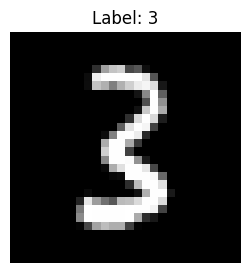

In [62]:
# ============================================================================
# CREATE DATALOADERS
# ============================================================================

train_dl = DataLoader(train_ds, bs)
valid_dl = DataLoader(valid_ds, bs)

print("DataLoaders created!")
print(f"  Batch size: {bs}")
print(f"  Training batches: {len(train_ds) // bs}")
print(f"  Validation batches: {len(valid_ds) // bs}")

# Test iteration
xb, yb = next(iter(valid_dl))  # Get first batch
print(f"\nFirst validation batch:")
print(f"  xb shape: {xb.shape}")
print(f"  yb shape: {yb.shape}")

# Visualize one sample from the batch
import matplotlib.pyplot as plt
plt.figure(figsize=(3, 3))
plt.imshow(xb[0].view(28, 28))
plt.title(f"Label: {yb[0].item()}")
plt.axis('off')
plt.show()

In [63]:
# ============================================================================
# CLEAN TRAINING LOOP WITH DATALOADER
# ============================================================================

model, opt = get_model()

def fit():
    """Training loop using DataLoader - the cleanest version yet!"""
    for epoch in range(epochs):
        # This is SO much cleaner!
        for xb, yb in train_dl:
            preds = model(xb)
            loss = loss_func(preds, yb)
            loss.backward()
            opt.step()
            opt.zero_grad()
        report(loss, preds, yb)

print("Training with DataLoader...")
print("Format: loss, accuracy")
fit()

# Check performance
print(f"\nFinal: loss={loss_func(model(xb), yb):.4f}, accuracy={accuracy(model(xb), yb):.2%}")

Training with DataLoader...
Format: loss, accuracy
0.11, 0.98
0.09, 0.98
0.06, 1.00

Final: loss=0.0326, accuracy=100.00%


### Adding Random Shuffling

For training, we want to **shuffle** the data each epoch. Why?
- Prevents the model from learning the order of examples
- Helps generalization
- But we DON'T shuffle validation data (order doesn't matter for evaluation)

Let's build a Sampler class to control the order of indices:

In [64]:
# ============================================================================
# SAMPLER CLASS - CONTROLS ORDER OF INDICES
# ============================================================================

import random

class Sampler:
    """
    Controls the order in which samples are accessed.

    Parameters:
    -----------
    ds : Dataset
        The dataset to sample from
    shuffle : bool
        If True, randomize order each iteration
    """
    def __init__(self, ds, shuffle=False):
        self.n = len(ds)      # Number of samples
        self.shuffle = shuffle

    def __iter__(self):
        """Yield indices in order (or shuffled order)."""
        res = list(range(self.n))  # [0, 1, 2, ..., n-1]
        if self.shuffle:
            random.shuffle(res)    # Randomize in-place
        return iter(res)

# Test samplers
print("Testing Samplers:")

# Sequential sampler (no shuffle)
ss = Sampler(train_ds, shuffle=False)
print(f"\nSequential (first 10 indices): {list(ss)[:10]}")

# Random sampler
rs = Sampler(train_ds, shuffle=True)
print(f"Random (first 10 indices): {list(rs)[:10]}")
print(f"Random again (different!): {list(Sampler(train_ds, shuffle=True))[:10]}")

Testing Samplers:

Sequential (first 10 indices): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Random (first 10 indices): [34645, 12079, 30955, 37240, 18487, 3348, 18459, 13845, 1710, 1294]
Random again (different!): [32536, 47584, 4226, 33501, 23674, 5258, 27921, 46989, 14084, 15173]


In [65]:
# ============================================================================
# BATCH SAMPLER - GROUPS INDICES INTO BATCHES
# ============================================================================
import fastcore.all as fc

class BatchSampler:
    """
    Groups indices from a Sampler into batches.

    Instead of yielding individual indices, yields lists of indices
    of size batch_size.
    """
    def __init__(self, sampler, bs, drop_last=False):
        # fc.store_attr() is a fastcore utility that does:
        # self.sampler = sampler
        # self.bs = bs
        # self.drop_last = drop_last
        fc.store_attr()

    def __iter__(self):
        """Yield batches of indices."""
        # fc.chunked groups items into chunks of size bs
        yield from fc.chunked(iter(self.sampler), self.bs, drop_last=self.drop_last)

# Test batch sampler
ss = Sampler(train_ds, shuffle=True)
bs_sampler = BatchSampler(ss, bs=4)

# Get first few batches of indices
from itertools import islice
print("Batch Sampler (first 5 batches of 4 indices each):")
for i, batch in enumerate(islice(bs_sampler, 5)):
    print(f"  Batch {i}: {batch}")

Batch Sampler (first 5 batches of 4 indices each):
  Batch 0: [9730, 42109, 21655, 33918]
  Batch 1: [11423, 7417, 19868, 48352]
  Batch 2: [12762, 30100, 45235, 9662]
  Batch 3: [26605, 19688, 26251, 38116]
  Batch 4: [24532, 24621, 42354, 6608]


In [66]:
# ============================================================================
# COLLATE FUNCTION - COMBINES SAMPLES INTO A BATCH
# ============================================================================

def collate(batch):
    """
    Combine a list of (x, y) tuples into batch tensors.

    Parameters:
    -----------
    batch : list of tuples
        List of (x, y) pairs from the dataset

    Returns:
    --------
    tuple
        (stacked_xs, stacked_ys) as tensors
    """
    # zip(*batch) unpacks the list of (x,y) tuples
    # into (list of xs, list of ys)
    xs, ys = zip(*batch)
    # Stack into single tensors
    return torch.stack(xs), torch.stack(ys)

# Test collate
samples = [train_ds[i] for i in [0, 1, 2]]  # Get 3 samples
print("Individual samples:")
for i, (x, y) in enumerate(samples):
    print(f"  Sample {i}: x shape {x.shape}, y = {y.item()}")

xs, ys = collate(samples)
print(f"\nAfter collate:")
print(f"  xs shape: {xs.shape}")
print(f"  ys shape: {ys.shape}")

Individual samples:
  Sample 0: x shape torch.Size([784]), y = 5
  Sample 1: x shape torch.Size([784]), y = 0
  Sample 2: x shape torch.Size([784]), y = 4

After collate:
  xs shape: torch.Size([3, 784])
  ys shape: torch.Size([3])


In [67]:
# ============================================================================
# DATALOADER WITH SAMPLER SUPPORT
# ============================================================================

class DataLoader:
    """
    DataLoader that uses a BatchSampler for flexible iteration.

    Supports:
    - Custom batch sampling (sequential or shuffled)
    - Custom collate functions
    """
    def __init__(self, ds, batchs, collate_fn=collate):
        fc.store_attr()

    def __iter__(self):
        """Yield collated batches."""
        # For each batch of indices from the batch sampler
        for b in self.batchs:
            # Get samples from dataset and collate them
            yield self.collate_fn(self.ds[i] for i in b)

# Create samplers and dataloaders
train_samp = BatchSampler(Sampler(train_ds, shuffle=True), bs)
valid_samp = BatchSampler(Sampler(valid_ds, shuffle=False), bs)

train_dl = DataLoader(train_ds, batchs=train_samp)
valid_dl = DataLoader(valid_ds, batchs=valid_samp)

print("DataLoaders with shuffling created!")

# Test
xb, yb = next(iter(train_dl))
print(f"\nTraining batch: xb shape {xb.shape}, yb shape {yb.shape}")

# Train
model, opt = get_model()
print("\nTraining with shuffled DataLoader...")
print("Format: loss, accuracy")
fit()

DataLoaders with shuffling created!

Training batch: xb shape torch.Size([50, 784]), yb shape torch.Size([50])

Training with shuffled DataLoader...
Format: loss, accuracy
0.13, 0.94
0.14, 0.96
0.13, 0.98


tensor(3)

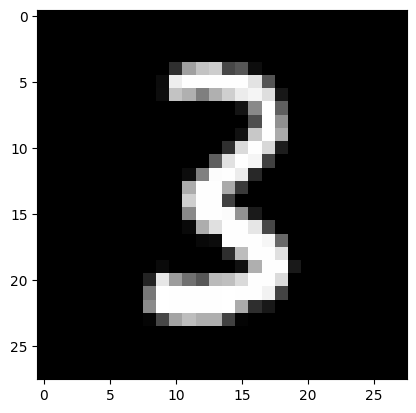

In [68]:
xb, yb = next(iter(valid_dl))
plt.imshow(xb[0].view(28, 28))
yb[0]

### 🎮 Interactive: the whole DataLoader assembly line

Everything we just built, animated in one place: the **Sampler** decides the *order* of indices (toggle shuffle, press “New epoch” — only the order changes, never the data itself), the **BatchSampler** chunks that order into groups of `bs` (toggle `drop_last` to discard the ragged final batch), and **collate** — click any batch! — fetches `ds[i]` for each index and stacks the samples into the `(xb, yb)` tensors your training loop consumes.

In [69]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/dataloader_pipeline.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/dataloader_pipeline.html",
#          width="100%", height=800)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/dataloader_pipeline.html", width="100%", height=800)


# Multiprocessing DataLoader


PyTorch's real `DataLoader` can fetch data using **several worker processes in parallel** (the `num_workers` argument). Before we use the built-in one, this short section builds a tiny version ourselves so the magic is no longer magic — and it all rests on one simple capability of our `Dataset`: **it can return a whole batch from a list of indices in a single call.**

**Why bother with multiple processes?**
In real training, *loading* the data is often slower than the GPU computing on it: reading files from disk, decoding JPEGs, resizing, applying augmentations. If the main process had to do all that, the GPU would sit idle waiting for the next batch. Instead, worker processes prepare *upcoming* batches while the GPU trains on the *current* one, so the two overlap and the GPU is kept fed. That overlap is the whole point of multiprocessing data loading.

In [70]:
# ============================================================================
# MULTIPROCESSING DATALOADER -- the imports
# ============================================================================
# torch.multiprocessing is PyTorch's drop-in replacement for Python's standard
# `multiprocessing` module. Its key advantage: it knows how to share TENSORS
# between processes efficiently (through shared memory) instead of slowly
# pickling and copying them. A DataLoader with n_workers>0 spins up several
# *worker processes*, and each one builds batches in parallel -- this is the
# module that makes passing those batches back to the main process fast.
import torch.multiprocessing as mp

# store_attr() is a tiny fastcore helper. Called inside an __init__, it
# automatically saves every argument as self.<name> -- so instead of writing
#     self.ds = ds; self.batchs = batchs; self.n_workers = n_workers; ...
# you just call store_attr() once. (fastcore is usually imported as `fc`, so
# you'll also see it written `fc.store_attr()`.)
from fastcore.basics import store_attr

In [71]:
# ----------------------------------------------------------------------------
# KEY IDEA #1: our Dataset can be indexed with a *list* of indices at once.
# ----------------------------------------------------------------------------
# train_ds[3] returns ONE sample. But train_ds[[3, 6, 8, 1]] returns FOUR
# samples stacked together in a single call -- effectively a whole batch --
# because the underlying x/y tensors support "fancy indexing" (indexing by a
# list or tensor of positions, not just one integer).
#
# Why this matters for multiprocessing: a worker can be handed an entire list
# of indices for one batch and grab them all in one operation, rather than
# looping over samples one at a time.
train_ds[[3, 6, 8, 1]]   # -> (x[[3,6,8,1]], y[[3,6,8,1]]) : a 4-sample batch

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([1, 1, 1, 0]))

In [72]:
# ----------------------------------------------------------------------------
# KEY IDEA #2: ds[...] is just syntactic sugar for ds.__getitem__(...)
# ----------------------------------------------------------------------------
# These two lines are IDENTICAL in effect:
#     train_ds[[3, 6, 8, 1]]
#     train_ds.__getitem__([3, 6, 8, 1])
# Writing the dunder method out explicitly matters here because in the NEXT
# cell we want to pass __getitem__ around *as a function* (to map()). The
# square-bracket syntax can't be passed as a value, but the method name can.
train_ds.__getitem__([3, 6, 8, 1])

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([1, 1, 1, 0]))

In [73]:
# ----------------------------------------------------------------------------
# KEY IDEA #3: map() applies __getitem__ to several index-lists in turn.
# ----------------------------------------------------------------------------
# We feed map() two batches' worth of indices: [3, 6] and [8, 1].
# map() calls train_ds.__getitem__([3, 6]) and then train_ds.__getitem__([8, 1]),
# yielding one (xb, yb) batch per index-list.
#
# THIS little loop is the heart of a multiprocessing DataLoader: take the
# epoch's indices, split them into per-batch chunks, then `map` __getitem__
# over those chunks. With workers, those calls are dispatched to PARALLEL
# processes -- so while the GPU trains on batch N, the workers are already
# fetching batches N+1, N+2, ... ready to hand over.
for o in map(train_ds.__getitem__, ([3, 6], [8, 1])): print(o)

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([1, 1]))
(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), tensor([1, 0]))


### What did those three cells just show us?

Taken together, the cells above reveal the entire trick behind a multiprocessing `DataLoader`:

1. **`train_ds[[3, 6, 8, 1]]`** — a `Dataset` indexed by a *list* returns a *batch* of samples at once (4 here), thanks to tensor fancy-indexing. **One call → one batch.**

2. **`train_ds.__getitem__([3, 6, 8, 1])`** — exactly the same operation, written the "long way." `ds[idxs]` is just sugar for `ds.__getitem__(idxs)`. We spell out the method name so we can hand it to `map` as a plain function.

3. **`map(train_ds.__getitem__, ([3, 6], [8, 1]))`** — `map` applies that function to each *list of indices*, producing one batch per list. This is a tiny, single-process preview of what the workers will do.

**How real multiprocessing uses this.** A DataLoader takes the epoch's (optionally shuffled) indices, chops them into per-batch chunks like `[3, 6]`, `[8, 1]`, …, and `map`s `__getitem__` over them — but distributes those calls across `n_workers` separate processes. Each worker independently calls `ds.__getitem__(chunk)`, builds its batch, and ships it back through a queue. (This is why `torch.multiprocessing`, with its shared-memory tensors, matters — plain copying would erase the speed-up.)

Let's now package exactly this idea into a small, reusable class.

In [74]:
# ============================================================================
# OUR OWN MULTIPROCESSING DATALOADER (a tiny ~6-line version)
# ============================================================================
class DataLoader():
  def __init__(self, ds, batchs, n_workers=1, collate_fn=collate):
    # store_attr() auto-saves EVERY argument as an attribute: self.ds,
    # self.batchs, self.n_workers, self.collate_fn -- shorthand for writing
    # those four `self.x = x` lines by hand. (fc = fastcore.)
    fc.store_attr()

  def __iter__(self):
    # __iter__ is what Python calls when you do `for batch in dl:` or iter(dl).
    # It contains `yield`, so it is a GENERATOR: batches are produced lazily,
    # one at a time, only as the training loop asks for them.
    #
    # mp.Pool(self.n_workers) launches a pool of N worker PROCESSES; the
    # `with` block guarantees they are cleaned up when iteration ends.
    with mp.Pool(self.n_workers) as ex:
      # ex.map(fn, iterable) runs fn(item) for each item -- in PARALLEL across
      # the worker processes -- and returns the results in order.
      # self.batchs yields LISTS of indices (one list per batch, e.g. [3,6,8,1]),
      # so each worker computes self.ds.__getitem__(those_indices) = one ready
      # batch. `yield from` re-emits each finished batch to the caller.
      yield from ex.map(self.ds.__getitem__, iter(self.batchs))

### Reading the `DataLoader` class line by line

Those ~6 lines *are* a working multiprocessing data loader. Here is every piece:

- **`def __init__(self, ds, batchs, n_workers=1, collate_fn=collate)`** — it takes the dataset `ds`, a `batchs` object that yields **lists of indices** (one list per batch — a `BatchSampler` does exactly this), how many worker processes to use (`n_workers`), and a `collate_fn`.

- **`fc.store_attr()`** — fastcore's `store_attr` saves *every* `__init__` argument as `self.<name>` automatically. It is a one-line replacement for `self.ds = ds; self.batchs = batchs; self.n_workers = n_workers; self.collate_fn = collate_fn`.

- **`def __iter__(self)`** — Python calls this whenever you write `for batch in dl:` or `iter(dl)`. Because it contains `yield`, it is a **generator**: batches are produced lazily, one at a time, only as the training loop asks — so you never hold a whole epoch in memory at once.

- **`with mp.Pool(self.n_workers) as ex:`** — opens a pool of `n_workers` separate worker **processes**. The `with` block guarantees the pool is shut down cleanly once iteration finishes.

- **`ex.map(self.ds.__getitem__, iter(self.batchs))`** — the payoff. `ex.map` takes our function (`self.ds.__getitem__`) and an iterable of inputs (`self.batchs`, which yields index-lists), then runs `ds.__getitem__(index_list)` **in parallel across the worker processes**, returning the finished batches in order. It is the very same `map(__getitem__, …)` from the cell above — just executed by a pool of processes instead of the main one.

- **`yield from …`** — re-emits each batch the pool produces, one by one, to whoever is iterating the DataLoader.

> **Why no explicit `collate` call here?** In the full PyTorch pipeline, `collate` stacks a *list of individual samples* into batch tensors. But our `Dataset` already returns a fully-stacked batch when indexed with a list (`ds[[3,6,8,1]]`), so each worker hands back a ready-made `(xb, yb)` — there is nothing left to collate. `collate_fn` is stored for API-compatibility but is not needed in this simplified version.

In [75]:
# Build our DataLoader: pass the dataset, a batch-sampler that yields LISTS of
# indices (train_samp = BatchSampler(RandomSampler(train_ds), bs, ...)), and
# ask for 2 worker processes.
train_dl = DataLoader(train_ds, batchs=train_samp, n_workers=2)
# iter(dl) triggers __iter__, which opens the worker Pool. `it` is now a
# generator we can pull batches from, one at a time, with next().
it = iter(train_dl)

In [76]:
# next(it) pulls ONE batch from the generator: a worker process fetched
# ds[batch_indices] and handed back the stacked (xb, yb) tensors.
xb, yb = next(it)
# Confirm the shapes: a batch of `bs` flattened 28x28 images (784 pixels each)
# and the matching labels -- e.g. (torch.Size([50, 784]), torch.Size([50])).
xb.shape, yb.shape

(torch.Size([50, 784]), torch.Size([50]))

### Interpreting the result, and when to use this

Running the two cells above prints something like `(torch.Size([50, 784]), torch.Size([50]))` — a batch of 50 flattened 28×28 images and their 50 labels, **fetched by a worker process** rather than the main one. From the training loop's point of view nothing changed: it still just iterates `for xb, yb in dl`. All the parallelism is hidden inside `__iter__`.

**Practical takeaways (these carry straight over to PyTorch's real `DataLoader`):**

- `n_workers` / `num_workers = 0` → everything runs in the main process. Simplest, easiest to debug, and the safe choice if you hit pickling errors or are on Windows/Jupyter.
- `n_workers` / `num_workers > 0` → that many background loader processes. A big win whenever data preparation (disk I/O, image decoding, augmentation) is the bottleneck and you want the workers racing ahead of the GPU.
- For any of this to work, the `Dataset` must support indexing by a list/array — exactly the capability the very first cell in this section verified.

This hand-rolled class is a **teaching toy** to demystify the mechanism. In real code you would use PyTorch's built-in `DataLoader` (next section), which does all this far more robustly — handling shuffling, pinned memory, timeouts, worker seeding, and graceful shutdown.

### PyTorch's Built-in DataLoader

PyTorch provides all this functionality (and much more) built-in! Let's use PyTorch's DataLoader with its samplers.

In [77]:
# ============================================================================
# PYTORCH'S BUILT-IN DATALOADER
# ============================================================================
#|export

from torch.utils.data import DataLoader, SequentialSampler, RandomSampler, BatchSampler

# PyTorch provides these samplers:
# - SequentialSampler: Access samples in order (0, 1, 2, ...)
# - RandomSampler: Access samples in random order

# Create batch samplers using PyTorch's classes
train_samp = BatchSampler(RandomSampler(train_ds), bs, drop_last=False)
valid_samp = BatchSampler(SequentialSampler(valid_ds), bs, drop_last=False)

# Create DataLoaders
train_dl = DataLoader(train_ds, batch_sampler=train_samp, collate_fn=collate)
valid_dl = DataLoader(valid_ds, batch_sampler=valid_samp, collate_fn=collate)

# Train
model, opt = get_model()
print("Training with PyTorch DataLoader...")
print("Format: loss, accuracy")
fit()
print(f"\nFinal: loss={loss_func(model(xb), yb):.4f}, accuracy={accuracy(model(xb), yb):.2%}")

Training with PyTorch DataLoader...
Format: loss, accuracy
0.10, 0.94
0.10, 0.96
0.27, 0.98

Final: loss=0.0834, accuracy=98.00%


### The Simplest DataLoader Usage

PyTorch DataLoader can auto-generate samplers for us. This is the most common usage:

In [78]:
# ============================================================================
# SIMPLEST DATALOADER USAGE
# ============================================================================

# PyTorch can generate samplers automatically!
# shuffle=True -> RandomSampler
# shuffle=False (default) -> SequentialSampler
# num_workers -> parallel data loading (very useful for slow data loading)

train_dl = DataLoader(train_ds, bs, shuffle=True, drop_last=True, num_workers=0)
valid_dl = DataLoader(valid_ds, bs, shuffle=False, num_workers=0)

# Note: num_workers=0 means load in main process
# Use num_workers>0 for parallel loading (faster but can cause issues on Windows)

print("Simple PyTorch DataLoader:")
print(f"  Training: shuffle=True, drop_last=True")
print(f"  Validation: shuffle=False")

# Train
model, opt = get_model()
print("\nTraining...")
print("Format: loss, accuracy")
fit()

print(f"\nFinal: loss={loss_func(model(xb), yb):.4f}, accuracy={accuracy(model(xb), yb):.2%}")

Simple PyTorch DataLoader:
  Training: shuffle=True, drop_last=True
  Validation: shuffle=False

Training...
Format: loss, accuracy
0.21, 0.92
0.15, 0.94
0.05, 0.98

Final: loss=0.1991, accuracy=94.00%


---

## Part 6: Validation - Checking for Overfitting

You **must** always have a **validation set** to check if your model is overfitting!

### What is Overfitting?

**Overfitting** happens when the model:
- Memorizes the training data
- But fails to generalize to new, unseen data

It's like a student who memorizes answers to practice problems but can't solve new problems.

```
+-----------------------------------------------------------------------------+
|                     TRAINING vs VALIDATION                                   |
+-----------------------------------------------------------------------------+
|                                                                             |
|   TRAINING SET (50,000 images):                                             |
|   - Used to update weights                                                  |
|   - Model sees these during training                                        |
|   - Loss goes down as model learns                                          |
|                                                                             |
|   VALIDATION SET (10,000 images):                                           |
|   - NOT used for training                                                   |
|   - Model never sees these during training                                  |
|   - Measures how well model generalizes                                     |
|                                                                             |
|   GOOD: Both training and validation metrics improve                        |
|   BAD:  Training improves but validation gets worse (overfitting!)          |
|                                                                             |
+-----------------------------------------------------------------------------+
```

### 🎮 Interactive: watch overfitting happen

Drag **epochs trained** and keep your eye on the two curves: the orange training loss falls forever (with enough capacity, the model can simply memorize), but the teal validation loss bottoms out and then turns *up* — that turning point is where the model stops learning patterns and starts memorizing quirks of the training set. Crank **model capacity** up and watch overfitting arrive earlier and bite harder. The dashed purple line marks where **early stopping** would halt training — and finding it is precisely why `fit()` runs the validation loop after every epoch.

In [79]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/overfitting_curves.html
# in an isolated <iframe> (its CSS/JS can't leak into the notebook).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# If you publish your notes online (GitHub Pages), you can instead point to
# the published copy, e.g.:
#   IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/overfitting_curves.html",
#          width="100%", height=620)
# ============================================================================
from IPython.display import IFrame
IFrame("https://shammun.github.io/shammunul-fastai-notes/notebooks/interactive_viz/overfitting_curves.html", width="100%", height=620)


### model.train() vs model.eval()

Some layers behave differently during training vs inference:
- **Dropout**: Randomly drops neurons during training, uses all during inference
- **BatchNorm**: Uses batch statistics during training, running stats during inference

Always call:
- `model.train()` before training
- `model.eval()` before validation/inference

For our simple model without Dropout/BatchNorm, this doesn't matter much, but it's a good habit!

In [80]:
# ============================================================================
# THE COMPLETE FIT FUNCTION WITH VALIDATION
# ============================================================================
#|export

def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
    """
    Train a model and validate after each epoch.

    Parameters:
    -----------
    epochs : int
        Number of training epochs
    model : nn.Module
        The neural network model
    loss_func : callable
        Loss function (e.g., F.cross_entropy)
    opt : optimizer
        Optimizer (e.g., optim.SGD)
    train_dl : DataLoader
        DataLoader for training data
    valid_dl : DataLoader
        DataLoader for validation data

    Returns:
    --------
    tuple
        Final (validation_loss, validation_accuracy)
    """
    for epoch in range(epochs):
        # =====================================================================
        # TRAINING PHASE
        # =====================================================================
        model.train()  # Set model to training mode
                       # (Affects Dropout, BatchNorm, etc.)

        for xb, yb in train_dl:
            # Forward pass
            loss = loss_func(model(xb), yb)
            # Backward pass
            loss.backward()
            # Update weights
            opt.step()
            # Zero gradients
            opt.zero_grad()

        # =====================================================================
        # VALIDATION PHASE
        # =====================================================================
        model.eval()  # Set model to evaluation mode

        # torch.no_grad() disables gradient computation
        # - Faster (don't need to store computation graph)
        # - Uses less memory
        # - We don't need gradients during evaluation!
        with torch.no_grad():
            # Accumulate loss and accuracy across all validation batches
            tot_loss = 0.0
            tot_acc = 0.0
            count = 0

            for xb, yb in valid_dl:
                pred = model(xb)
                n = len(xb)
                count += n
                # .item() converts single-value tensor to Python number
                tot_loss += loss_func(pred, yb).item() * n
                tot_acc += accuracy(pred, yb).item() * n

        # Print epoch number, average loss, average accuracy
        avg_loss = tot_loss / count
        avg_acc = tot_acc / count
        print(f"Epoch {epoch}: loss={avg_loss:.4f}, accuracy={avg_acc:.2%}")

    return avg_loss, avg_acc

print("fit() function with validation defined!")
print("\nThis function:")
print("  1. Trains on training data each epoch")
print("  2. Evaluates on validation data after each epoch")
print("  3. Returns final validation metrics")

fit() function with validation defined!

This function:
  1. Trains on training data each epoch
  2. Evaluates on validation data after each epoch
  3. Returns final validation metrics


In [81]:
# ============================================================================
# HELPER FUNCTION TO CREATE DATALOADERS
# ============================================================================
#|export

def get_dls(train_ds, valid_ds, bs, **kwargs):
    """
    Create training and validation DataLoaders.

    Parameters:
    -----------
    train_ds : Dataset
        Training Dataset
    valid_ds : Dataset
        Validation Dataset
    bs : int
        Batch size for training
    **kwargs : dict
        Additional arguments passed to DataLoader (e.g., num_workers)

    Returns:
    --------
    tuple
        (train_dl, valid_dl) - DataLoaders for training and validation

    Notes:
    - Training uses shuffle=True (randomize order each epoch)
    - Validation uses 2x batch size (can fit more since no gradients stored)
    - Validation doesn't shuffle (order doesn't matter for evaluation)
    """
    return (
        DataLoader(train_ds, batch_size=bs, shuffle=True, **kwargs),
        DataLoader(valid_ds, batch_size=bs*2, **kwargs)  # 2x batch size for validation!
    )

print("get_dls() helper function defined!")
print("\nNotes:")
print("  - Training: shuffle=True")
print("  - Validation: 2x batch size (no gradients = more memory available)")

get_dls() helper function defined!

Notes:
  - Training: shuffle=True
  - Validation: 2x batch size (no gradients = more memory available)


### Putting It All Together

Now our complete training pipeline is just a few lines:

In [82]:
# ============================================================================
# THE COMPLETE TRAINING PIPELINE
# ============================================================================
# Our whole process is now just 3 lines!

# 1. Create DataLoaders
train_dl, valid_dl = get_dls(train_ds, valid_ds, bs)

# 2. Create model and optimizer
model, opt = get_model()

# 3. Train with validation!
print("="*60)
print("TRAINING WITH VALIDATION")
print("="*60)
loss, acc = fit(5, model, loss_func, opt, train_dl, valid_dl)

print("="*60)
print(f"Final Validation Results:")
print(f"  Loss:     {loss:.4f}")
print(f"  Accuracy: {acc:.2%}")
print("="*60)

TRAINING WITH VALIDATION
Epoch 0: loss=0.1484, accuracy=95.66%
Epoch 1: loss=0.1190, accuracy=96.63%
Epoch 2: loss=0.1228, accuracy=96.24%
Epoch 3: loss=0.1085, accuracy=96.84%
Epoch 4: loss=0.1082, accuracy=97.06%
Final Validation Results:
  Loss:     0.1082
  Accuracy: 97.06%


---

## Summary: What We Learned

We built a complete neural network training pipeline from scratch!

### The Complete Journey

```
+-----------------------------------------------------------------------------+
|                        MINIBATCH TRAINING SUMMARY                           |
+-----------------------------------------------------------------------------+
|                                                                             |
|   PART 1-2: SETUP & MODEL                                                   |
|   -----------------------                                                   |
|   - Loaded MNIST data (50k train, 10k valid images)                         |
|   - Built simple MLP: 784 -> 50 -> 10                                       |
|                                                                             |
|   PART 2: CROSS-ENTROPY LOSS                                                |
|   ---------------------------                                               |
|   - Softmax: Convert logits to probabilities                                |
|   - LogSumExp trick: Numerical stability                                    |
|   - NLL Loss: -log(p[correct_class])                                       |
|   - F.cross_entropy: Combined, efficient version                            |
|                                                                             |
|   PART 3: TRAINING LOOP                                                     |
|   ----------------------                                                    |
|   - Minibatches: Process data in small chunks                               |
|   - Forward -> Loss -> Backward -> Update -> Zero gradients                 |
|   - Repeat for all batches (epoch) x multiple epochs                        |
|                                                                             |
|   PART 4: OPTIMIZERS                                                        |
|   -------------------                                                       |
|   - model.parameters(): Auto-find all learnable params                      |
|   - optim.SGD: Stochastic Gradient Descent optimizer                        |
|   - opt.step() / opt.zero_grad(): Clean update code                         |
|                                                                             |
|   PART 5: DATASET & DATALOADER                                              |
|   -----------------------------                                             |
|   - Dataset: __getitem__ and __len__                                        |
|   - DataLoader: Batching, shuffling, parallelism                            |
|   - Sampler: Controls the order of samples                                  |
|                                                                             |
|   PART 6: VALIDATION                                                        |
|   ------------------                                                        |
|   - Separate validation set to check generalization                         |
|   - model.train() vs model.eval()                                           |
|   - torch.no_grad() during evaluation                                       |
|                                                                             |
+-----------------------------------------------------------------------------+
```

### Key Functions We Built

| Function | Purpose |
|----------|---------|
| `accuracy(out, yb)` | Compute classification accuracy |
| `report(loss, preds, yb)` | Print loss and accuracy |
| `fit(epochs, model, ...)` | Complete training loop with validation |
| `get_dls(train_ds, valid_ds, bs)` | Create training and validation DataLoaders |

### Key PyTorch Components

| Component | What It Does |
|-----------|--------------|
| `nn.Module` | Base class for all neural network modules |
| `nn.Linear` | Fully connected layer |
| `nn.Sequential` | Container for sequential layers |
| `F.cross_entropy` | Loss function for classification |
| `torch.optim.SGD` | Stochastic Gradient Descent optimizer |
| `DataLoader` | Batches and shuffles data |

### What's Next?

In the following notebooks, we'll learn:
- More advanced optimizers (Adam, AdamW)
- Learning rate schedulers
- Data augmentation
- Regularization techniques (Dropout, Weight Decay)
- More complex architectures (CNNs, ResNets)

**Congratulations! You now know how to train a neural network from scratch!**

---

## Export

The following cell exports the key functions to a Python module using nbdev.

In [83]:
# ============================================================================
# EXPORT TO PYTHON MODULE
# ============================================================================
# nbdev.nbdev_export() extracts all cells marked with #|export
# and saves them to a .py file

# import nbdev
# nbdev.nbdev_export()

# print("Exported!")